# **Assignment 02: Object Detection**

**Available:** Aug 26, 2025 until Sep 4, 2025 11:59pm

## Tasks:

1. Object Detection- refer to slides 8/26/2025 class
2. https://www.kaggle.com/datasets/awsaf49/coco-2017-dataset
3. Run detection performance comparing (inference only):
    - Faster R-CNN
    - DETR
    - DINO
    - Grounding DINO (use text prompt at your discretion)
4. Grading Criteria:
    - Report
    - Code
    - Video
    - Insight


## **Import Packages and Setup**

In [15]:
## Import Libraries

# Set CUDA_VISIBLE_DEVICES to make both GPUs visible
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0,1'

# Install all packages for from the requirements.txt
%pip install -r requirements.txt

import torch
import torch.nn as nn
import torchvision
import cv2
import matplotlib.pyplot as plt
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import ImageFolder
from torchvision import transforms
from torch import optim
from tqdm.notebook import tqdm
from torchinfo import summary
import einops
import PIL
import numpy as np
import pandas as pd
# Use a pipeline as a high-level helper
from transformers import pipeline
import time
import psutil
import gc
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
from collections import defaultdict
import numpy as np

# Authorize Huggingface account
from dotenv import load_dotenv
import os

# Load environment variables from .env file
load_dotenv('/mnt/Storage02/SoftwareDev/CAP_6411_Assignments/.env')

# Get Hugging Face token
hf_token = os.getenv('HUGGINGFACE_HUB_TOKEN') or os.getenv('HF_TOKEN')

if hf_token:
    print("Found Hugging Face token in environment variables")
    
    
    from huggingface_hub import login, whoami
    
    try:
        # Login to Hugging Face Hub
        login(token=hf_token)
        
        # Verify login by getting user info
        user_info = whoami()
        print(f"Successfully authenticated with Hugging Face!")
        print(f"Logged in as: {user_info['name']}")
        
        # Set the token as environment variable for other libraries
        os.environ['HUGGINGFACE_HUB_TOKEN'] = hf_token
        os.environ['HF_TOKEN'] = hf_token
        
    except Exception as e:
        print(f"Authentication failed: {e}")
        print("Will proceed without pre-trained models if needed")
        hf_token = None
else:
    print("No Hugging Face token found in .env file")
    print("Please add HUGGINGFACE_HUB_TOKEN=your_token_here to your .env file")
    hf_token = None

# Comprehensive GPU diagnostics
print("\n=== GPU Diagnostics ===")
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
print(f"Number of GPUs detected: {torch.cuda.device_count()}")

if torch.cuda.is_available():
    print("\n=== All Available GPUs ===")
    for i in range(torch.cuda.device_count()):
        props = torch.cuda.get_device_properties(i)
        print(f"GPU {i}:")
        print(f"  Name: {props.name}")
        print(f"  Total Memory: {props.total_memory / 1024**3:.2f} GB")
        print(f"  Multi-processor count: {props.multi_processor_count}")
        print(f"  Compute Capability: {props.major}.{props.minor}")
        print()

# Device selection with preference for cuda:1 (A6000) -> cuda:0 (4090) -> cpu
if torch.cuda.is_available() and torch.cuda.device_count() > 1:
    device = torch.device('cuda:1')  # This should now be your A6000!
    print(f"Using GPU 1: {torch.cuda.get_device_name(1)}")
elif torch.cuda.is_available():
    device = torch.device('cuda:0')
    print(f"Using GPU 0: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device('cpu')
    print("Using CPU")

print(f"Selected device: {device}")

# If no logs folder exists, create one
if not os.path.exists("logs"):
    os.makedirs("logs")

# If no checkpoints folder exists, create one
if not os.path.exists("checkpoints"):
    os.makedirs("checkpoints")

# If no data folder exists, create one
if not os.path.exists("data"):
    os.makedirs("data")

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    return 0

Note: you may need to restart the kernel to use updated packages.
Found Hugging Face token in environment variables
Note: you may need to restart the kernel to use updated packages.
Found Hugging Face token in environment variables


Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Successfully authenticated with Hugging Face!
Logged in as: malneyugnfl

=== GPU Diagnostics ===
PyTorch version: 2.8.0+cu128
CUDA available: True
CUDA version: 12.8
Number of GPUs detected: 2

=== All Available GPUs ===
GPU 0:
  Name: NVIDIA GeForce RTX 4090 Laptop GPU
  Total Memory: 15.70 GB
  Multi-processor count: 76
  Compute Capability: 8.9

GPU 1:
  Name: NVIDIA RTX A6000
  Total Memory: 47.53 GB
  Multi-processor count: 84
  Compute Capability: 8.6

Using GPU 1: NVIDIA RTX A6000
Selected device: cuda:1


## **Import and Process Data**

In [2]:
# Import Dataset and Process it

import json
from PIL import Image
from torch.utils.data import Dataset
import os

class CocoDataset(Dataset):
    """
    Custom PyTorch Dataset class for loading COCO 2017 data.
    
    This class handles loading images and their corresponding annotations from the COCO dataset,
    making it compatible with PyTorch DataLoaders and various object detection models.
    """
    
    def __init__(self, root_dir, split="val2017", annotation_type="instances", transform=None, return_coco=False):
        """
        Initialize the COCO dataset.
        
        Args:
            root_dir (str): Path to the COCO dataset root directory (should contain 'annotations', 'train2017', 'val2017', etc.)
            split (str): Dataset split - one of 'train2017', 'val2017', or 'test2017'
            annotation_type (str): Type of annotations - 'instances', 'captions', or 'person_keypoints'
            transform (callable, optional): Transform to apply to images and targets
            return_coco (bool): If True, also return the raw COCO annotation dict for each sample
        """
        # Store initialization parameters
        self.root_dir = root_dir
        self.split = split
        self.transform = transform
        self.return_coco = return_coco
        
        # Set up image directory path
        self.img_dir = os.path.join(root_dir, split)
        self.annotation_type = annotation_type
        
        # Handle test split (which has no annotations)
        if split == "test2017":
            self.annotations = None
            # For test set, just get list of image filenames
            self.imgs = sorted(os.listdir(self.img_dir))
        else:
            # Load annotation file for train/val splits
            ann_file = os.path.join(
                root_dir, "annotations", f"{annotation_type}_{split}.json"
            )
            
            # Load COCO annotations JSON file
            with open(ann_file, "r") as f:
                self.coco = json.load(f)
            
            # Extract images and annotations from COCO data
            self.imgs = self.coco["images"]  # List of image metadata
            self.anns = self.coco["annotations"]  # List of annotation objects
            
            # Create mapping from image_id to list of annotations for that image
            # This allows fast lookup of annotations for a given image
            self.imgid_to_anns = {}
            for ann in self.anns:
                img_id = ann["image_id"]
                if img_id not in self.imgid_to_anns:
                    self.imgid_to_anns[img_id] = []
                self.imgid_to_anns[img_id].append(ann)
            
            # Create mapping from image_id to filename for easy access
            self.imgid_to_filename = {img["id"]: img["file_name"] for img in self.imgs}
            
            # Create mapping from category_id to category name (useful for visualization)
            self.catid_to_name = {cat["id"]: cat["name"] for cat in self.coco.get("categories", [])}

    def __len__(self):
        """Return the total number of images in the dataset."""
        return len(self.imgs)

    def __getitem__(self, idx):
        """
        Get a single sample from the dataset.
        
        Args:
            idx (int): Index of the sample to retrieve
            
        Returns:
            tuple: (image, target) where:
                - image: PIL Image or transformed tensor
                - target: Dictionary containing bounding boxes, labels, and other metadata
        """
        
        # Handle test split (no annotations available)
        if self.split == "test2017":
            img_name = self.imgs[idx]
            img_path = os.path.join(self.img_dir, img_name)
            image = Image.open(img_path).convert("RGB")
            target = {}  # Empty target for test images
        else:
            # Get image metadata and construct path
            img_info = self.imgs[idx]
            img_id = img_info["id"]
            img_name = img_info["file_name"]
            img_path = os.path.join(self.img_dir, img_name)
            
            # Load image and convert to RGB
            image = Image.open(img_path).convert("RGB")
            
            # Get all annotations for this image
            anns = self.imgid_to_anns.get(img_id, [])
            
            # Extract bounding box and label information from annotations
            boxes = []      # Bounding boxes in [x, y, width, height] format
            labels = []     # Category IDs for each object
            areas = []      # Area of each bounding box
            iscrowd = []    # Whether each annotation represents a crowd of objects
            
            for ann in anns:
                # Only process annotations that have bounding boxes
                if "bbox" in ann:
                    boxes.append(ann["bbox"])  # COCO format: [x, y, width, height]
                    labels.append(ann["category_id"])
                    areas.append(ann.get("area", 0))
                    iscrowd.append(ann.get("iscrowd", 0))
            
            # Create target dictionary in PyTorch format
            # Convert lists to tensors, handling empty cases
            target = {
                "boxes": torch.tensor(boxes, dtype=torch.float32) if boxes else torch.zeros((0,4), dtype=torch.float32),
                "labels": torch.tensor(labels, dtype=torch.int64) if labels else torch.zeros((0,), dtype=torch.int64),
                "image_id": torch.tensor([img_id]),  # Unique identifier for this image
                "area": torch.tensor(areas, dtype=torch.float32) if areas else torch.zeros((0,), dtype=torch.float32),
                "iscrowd": torch.tensor(iscrowd, dtype=torch.int64) if iscrowd else torch.zeros((0,), dtype=torch.int64),
            }
        
        # Apply transforms if provided (e.g., normalization, resizing)
        if self.transform:
            image = self.transform(image)
        
        # Optionally return raw COCO annotations along with processed data
        if self.return_coco and self.split != "test2017":
            return image, target, anns
        
        return image, target

# Example usage:
# Create a dataset instance
# dataset = CocoDataset(
#     root_dir="data/coco2017",              # Path to COCO dataset
#     split="val2017",                       # Use validation split
#     annotation_type="instances",           # Object detection annotations
#     transform=transforms.ToTensor(),       # Convert PIL Images to tensors
# )
# 
# # Get a single sample
# img, target = dataset[0]
# print(f"Image shape: {img.shape}")
# print(f"Number of objects: {len(target['labels'])}")
# print(f"Object categories: {target['labels']}")
# print(f"Bounding boxes: {target['boxes']}")
#
# # Use with DataLoader for batching
# from torch.utils.data import DataLoader
# dataloader = DataLoader(dataset, batch_size=4, shuffle=True)
# for batch_imgs, batch_targets in dataloader:
#     # Process batch
#     break

In [3]:
# Create Instance of dataset for inference

# Define transforms for inference (normalize to match model expectations)
inference_transform = transforms.Compose([
    transforms.ToTensor(),  # Convert PIL Image to tensor and scale to [0,1]
    # Note: Different models may need different normalization
    # We'll apply model-specific transforms during inference
])

# Create dataset instance pointing to the COCO 2017 validation set
coco_dataset = CocoDataset(
    root_dir="data/coco2017",           # Path to COCO dataset
    split="val2017",                    # Use validation split for inference
    annotation_type="instances",        # Object detection annotations
    transform=inference_transform,      # Apply transforms
    return_coco=False                   # Don't need raw COCO annotations for inference
)

print(f"Dataset loaded successfully!")
print(f"Number of images in validation set: {len(coco_dataset)}")
print(f"Available categories: {len(coco_dataset.catid_to_name)} classes")

# Define a proper collate function that can be pickled
def collate_fn(batch):
    """
    Custom collate function for object detection.
    Since we're using batch_size=1, this just returns the batch as-is.
    """
    return batch

# Create DataLoader for batched inference
# Using batch_size=1 for inference to avoid complications with variable-sized images
inference_dataloader = DataLoader(
    coco_dataset,
    batch_size=1,                       # Process one image at a time
    shuffle=False,                      # No need to shuffle for inference
    num_workers=0,                      # Set to 0 to avoid pickling issues with custom classes
    collate_fn=collate_fn,             # Use proper function instead of lambda
    pin_memory=True if torch.cuda.is_available() else False  # Speed up GPU transfer
)

print(f"DataLoader created with batch size: {inference_dataloader.batch_size}")
print(f"Number of batches: {len(inference_dataloader)}")

# Test loading a single sample to verify everything works
print("\n=== Testing dataset loading ===")
try:
    sample_image, sample_target = coco_dataset[0]
    print(f"Sample loaded successfully!")
    print(f"Image shape: {sample_image.shape}")
    print(f"Image dtype: {sample_image.dtype}")
    print(f"Number of objects in image: {len(sample_target['labels'])}")
    print(f"Object categories in image: {sample_target['labels'].tolist()}")
    print(f"Image ID: {sample_target['image_id'].item()}")
    
    # Show some category names if available
    if len(sample_target['labels']) > 0:
        print("Category names:")
        for label in sample_target['labels'][:5]:  # Show first 5 categories
            cat_name = coco_dataset.catid_to_name.get(label.item(), f"Unknown ({label.item()})")
            print(f"  - {cat_name}")
            
except Exception as e:
    print(f"Error loading sample: {e}")

# Test DataLoader iteration
print("\n=== Testing DataLoader ===")
try:
    # Get first batch
    first_batch = next(iter(inference_dataloader))
    image, target = first_batch[0]  # Extract from list since batch_size=1
    print(f"DataLoader working correctly!")
    print(f"Batch image shape: {image.shape}")
    print(f"Batch target keys: {list(target.keys())}")
    
except Exception as e:
    print(f"Error with DataLoader: {e}")

Dataset loaded successfully!
Number of images in validation set: 5000
Available categories: 80 classes
DataLoader created with batch size: 1
Number of batches: 5000

=== Testing dataset loading ===
Sample loaded successfully!
Image shape: torch.Size([3, 427, 640])
Image dtype: torch.float32
Number of objects in image: 19
Object categories in image: [44, 67, 1, 49, 51, 51, 79, 1, 47, 47, 51, 51, 56, 50, 56, 56, 79, 57, 81]
Image ID: 397133
Category names:
  - bottle
  - dining table
  - person
  - knife
  - bowl

=== Testing DataLoader ===
DataLoader working correctly!
Batch image shape: torch.Size([3, 427, 640])
Batch target keys: ['boxes', 'labels', 'image_id', 'area', 'iscrowd']


## **Faster R-CNN**

### Import Faster R-CNN

In [19]:
# Load Faster R-CNN model
from torchvision.models import detection
import torchvision.transforms as T

# Load pre-trained Faster R-CNN model with ResNet-50 backbone
faster_rcnn = detection.fasterrcnn_resnet50_fpn(pretrained=True)
faster_rcnn.eval()  # Set to evaluation mode
faster_rcnn = faster_rcnn.to(device)


/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=FasterRCNN_ResNet50_FPN_Weights.COCO_V1`. You can also use `weights=FasterRCNN_ResNet50_FPN_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


### Perform Inference and Measure Performance Metrics for Faster R-CNN

In [20]:
# Faster R-CNN Inference with Performance Metrics


# COCO class names for visualization
COCO_CLASSES = [
    '__background__', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus',
    'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'N/A', 'stop sign',
    'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow',
    'elephant', 'bear', 'zebra', 'giraffe', 'N/A', 'backpack', 'umbrella', 'N/A', 'N/A',
    'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball',
    'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket',
    'bottle', 'N/A', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl',
    'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza',
    'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'N/A', 'dining table',
    'N/A', 'N/A', 'toilet', 'N/A', 'tv', 'laptop', 'mouse', 'remote', 'keyboard',
    'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'N/A', 'book',
    'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', 'toothbrush'
]

def faster_rcnn_inference(model, image_tensor, confidence_threshold=0.5):
    """
    Perform inference with Faster R-CNN
    
    Args:
        model: Faster R-CNN model
        image_tensor: Input image tensor [C, H, W]
        confidence_threshold: Minimum confidence score for detections
    
    Returns:
        dict: Detection results with boxes, labels, scores
    """
    # Ensure image is in the right format [1, C, H, W]
    if image_tensor.dim() == 3:
        image_tensor = image_tensor.unsqueeze(0)
    
    # Move to device
    image_tensor = image_tensor.to(device)
    
    # Inference
    with torch.no_grad():
        predictions = model(image_tensor)
    
    # Extract results from the first (and only) image in batch
    pred = predictions[0]
    
    # Filter by confidence threshold
    valid_detections = pred['scores'] >= confidence_threshold
    
    return {
        'boxes': pred['boxes'][valid_detections].cpu(),
        'labels': pred['labels'][valid_detections].cpu(),
        'scores': pred['scores'][valid_detections].cpu()
    }

def convert_to_coco_format(image_id, detections):
    """
    Convert model predictions to COCO evaluation format
    
    Args:
        image_id: COCO image ID
        detections: Detection results from model
    
    Returns:
        list: List of detections in COCO format
    """
    coco_results = []
    
    for i in range(len(detections['boxes'])):
        box = detections['boxes'][i].numpy()
        # Convert from [x1, y1, x2, y2] to [x, y, width, height]
        x1, y1, x2, y2 = box
        width = x2 - x1
        height = y2 - y1
        
        coco_results.append({
            'image_id': int(image_id),
            'category_id': int(detections['labels'][i].item()),
            'bbox': [float(x1), float(y1), float(width), float(height)],
            'score': float(detections['scores'][i].item())
        })
    
    return coco_results

# Initialize performance tracking
print("=== Faster R-CNN Inference and Performance Evaluation ===\n")

# Set up evaluation parameters
CONFIDENCE_THRESHOLD = 0.5
MAX_IMAGES = 100  # Limit for faster evaluation during development
USE_SUBSET = True  # Set to False to evaluate on full validation set

# Performance metrics storage
inference_times = []
memory_usage_before = []
memory_usage_after = []
gpu_memory_before = []
gpu_memory_after = []
total_detections = 0
coco_results = []

# Track overall timing
overall_start_time = time.time()

print(f"Starting inference on {'subset of' if USE_SUBSET else 'full'} COCO validation set...")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"Device: {device}")
print(f"Initial CPU Memory: {get_memory_usage():.2f} MB")
print(f"Initial GPU Memory: {get_gpu_memory_usage():.2f} MB")
print()

# Ensure model is in evaluation mode and on correct device
faster_rcnn.eval()
faster_rcnn = faster_rcnn.to(device)

# Create a subset of the dataset for faster evaluation
dataset_subset = coco_dataset if not USE_SUBSET else torch.utils.data.Subset(
    coco_dataset, range(min(MAX_IMAGES, len(coco_dataset)))
)

# Create DataLoader for the subset
subset_dataloader = DataLoader(
    dataset_subset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Processing {len(dataset_subset)} images...")

# Perform inference on dataset
for batch_idx, batch in enumerate(tqdm(subset_dataloader, desc="Faster R-CNN Inference")):
    image, target = batch[0]  # Extract from batch list
    image_id = target['image_id'].item()
    
    # Record memory usage before inference
    mem_before = get_memory_usage()
    gpu_mem_before = get_gpu_memory_usage()
    memory_usage_before.append(mem_before)
    gpu_memory_before.append(gpu_mem_before)
    
    # Time the inference
    start_time = time.time()
    
    # Perform inference
    detections = faster_rcnn_inference(faster_rcnn, image, CONFIDENCE_THRESHOLD)
    
    # Record inference time
    inference_time = time.time() - start_time
    inference_times.append(inference_time)
    
    # Record memory usage after inference
    mem_after = get_memory_usage()
    gpu_mem_after = get_gpu_memory_usage()
    memory_usage_after.append(mem_after)
    gpu_memory_after.append(gpu_mem_after)
    
    # Convert to COCO format for evaluation
    coco_detections = convert_to_coco_format(image_id, detections)
    coco_results.extend(coco_detections)
    
    # Update total detections count
    total_detections += len(detections['boxes'])
    
    # Print progress every 10 images
    if (batch_idx + 1) % 10 == 0:
        avg_time = np.mean(inference_times[-10:])
        print(f"Processed {batch_idx + 1} images, avg time (last 10): {avg_time:.3f}s")

# Calculate overall timing
total_inference_time = time.time() - overall_start_time

print(f"\n=== Faster R-CNN Performance Metrics ===")
print(f"Dataset: COCO 2017 Validation ({'subset' if USE_SUBSET else 'full'})")
print(f"Images processed: {len(dataset_subset)}")
print(f"Total detections: {total_detections}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")

# Timing metrics
print(f"\n--- Timing Metrics ---")
print(f"Total inference time: {total_inference_time:.2f} seconds")
print(f"Average time per image: {np.mean(inference_times):.3f} ± {np.std(inference_times):.3f} seconds")
print(f"Fastest inference: {np.min(inference_times):.3f} seconds")
print(f"Slowest inference: {np.max(inference_times):.3f} seconds")
print(f"Images per second: {len(dataset_subset) / total_inference_time:.2f}")

# Memory metrics
print(f"\n--- Memory Usage Metrics ---")
print(f"Average CPU memory during inference: {np.mean(memory_usage_after):.2f} MB")
print(f"Peak CPU memory usage: {np.max(memory_usage_after):.2f} MB")
print(f"Average CPU memory increase per inference: {np.mean(np.array(memory_usage_after) - np.array(memory_usage_before)):.2f} MB")

if torch.cuda.is_available():
    print(f"Average GPU memory during inference: {np.mean(gpu_memory_after):.2f} MB")
    print(f"Peak GPU memory usage: {np.max(gpu_memory_after):.2f} MB")
    print(f"Average GPU memory increase per inference: {np.mean(np.array(gpu_memory_after) - np.array(gpu_memory_before)):.2f} MB")

# Detection statistics
print(f"\n--- Detection Statistics ---")
print(f"Average detections per image: {total_detections / len(dataset_subset):.2f}")
scores_all = [det['score'] for det in coco_results]
if scores_all:
    print(f"Average confidence score: {np.mean(scores_all):.3f} ± {np.std(scores_all):.3f}")
    print(f"Confidence score range: {np.min(scores_all):.3f} - {np.max(scores_all):.3f}")

# Save results for COCO evaluation
results_file = f"logs/faster_rcnn_results_{len(dataset_subset)}_images.json"
with open(results_file, 'w') as f:
    json.dump(coco_results, f)
print(f"\nResults saved to: {results_file}")

# Store results for comparison with other models
faster_rcnn_metrics = {
    'model_name': 'Faster R-CNN',
    'total_images': len(dataset_subset),
    'total_detections': total_detections,
    'total_inference_time': total_inference_time,
    'avg_time_per_image': np.mean(inference_times),
    'std_time_per_image': np.std(inference_times),
    'images_per_second': len(dataset_subset) / total_inference_time,
    'avg_cpu_memory': np.mean(memory_usage_after),
    'peak_cpu_memory': np.max(memory_usage_after),
    'avg_gpu_memory': np.mean(gpu_memory_after) if torch.cuda.is_available() else 0,
    'peak_gpu_memory': np.max(gpu_memory_after) if torch.cuda.is_available() else 0,
    'avg_detections_per_image': total_detections / len(dataset_subset),
    'avg_confidence': np.mean(scores_all) if scores_all else 0,
    'confidence_threshold': CONFIDENCE_THRESHOLD
}

print(f"\n=== Summary for Faster R-CNN ===")
print(f"✓ Processed {len(dataset_subset)} images in {total_inference_time:.2f} seconds")
print(f"✓ Average inference speed: {len(dataset_subset) / total_inference_time:.2f} images/second")
print(f"✓ Average detections per image: {total_detections / len(dataset_subset):.2f}")
print(f"✓ Results saved for COCO evaluation")

# Clean up GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print(f"\n✓ Faster R-CNN inference completed successfully!")

=== Faster R-CNN Inference and Performance Evaluation ===

Starting inference on subset of COCO validation set...
Confidence threshold: 0.5
Device: cuda:1
Initial CPU Memory: 2929.73 MB
Initial GPU Memory: 0.00 MB

Processing 100 images...


Faster R-CNN Inference:   0%|          | 0/100 [00:00<?, ?it/s]

Processed 10 images, avg time (last 10): 0.037s
Processed 20 images, avg time (last 10): 0.030s
Processed 20 images, avg time (last 10): 0.030s
Processed 30 images, avg time (last 10): 0.031s
Processed 30 images, avg time (last 10): 0.031s
Processed 40 images, avg time (last 10): 0.029s
Processed 40 images, avg time (last 10): 0.029s
Processed 50 images, avg time (last 10): 0.029s
Processed 50 images, avg time (last 10): 0.029s
Processed 60 images, avg time (last 10): 0.029s
Processed 60 images, avg time (last 10): 0.029s
Processed 70 images, avg time (last 10): 0.030s
Processed 70 images, avg time (last 10): 0.030s
Processed 80 images, avg time (last 10): 0.029s
Processed 80 images, avg time (last 10): 0.029s
Processed 90 images, avg time (last 10): 0.029s
Processed 90 images, avg time (last 10): 0.029s
Processed 100 images, avg time (last 10): 0.029s

=== Faster R-CNN Performance Metrics ===
Dataset: COCO 2017 Validation (subset)
Images processed: 100
Total detections: 940
Confidence


=== COCO Evaluation Metrics ===
loading annotations into memory...
Done (t=0.26s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
Done (t=0.26s)
creating index...
index created!
Loading and preparing results...
DONE (t=0.01s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.11s).
Accumulating evaluation results...
DONE (t=0.11s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.427
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.600
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.486
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.267
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.483
 Average Precision  (AP) @[ 

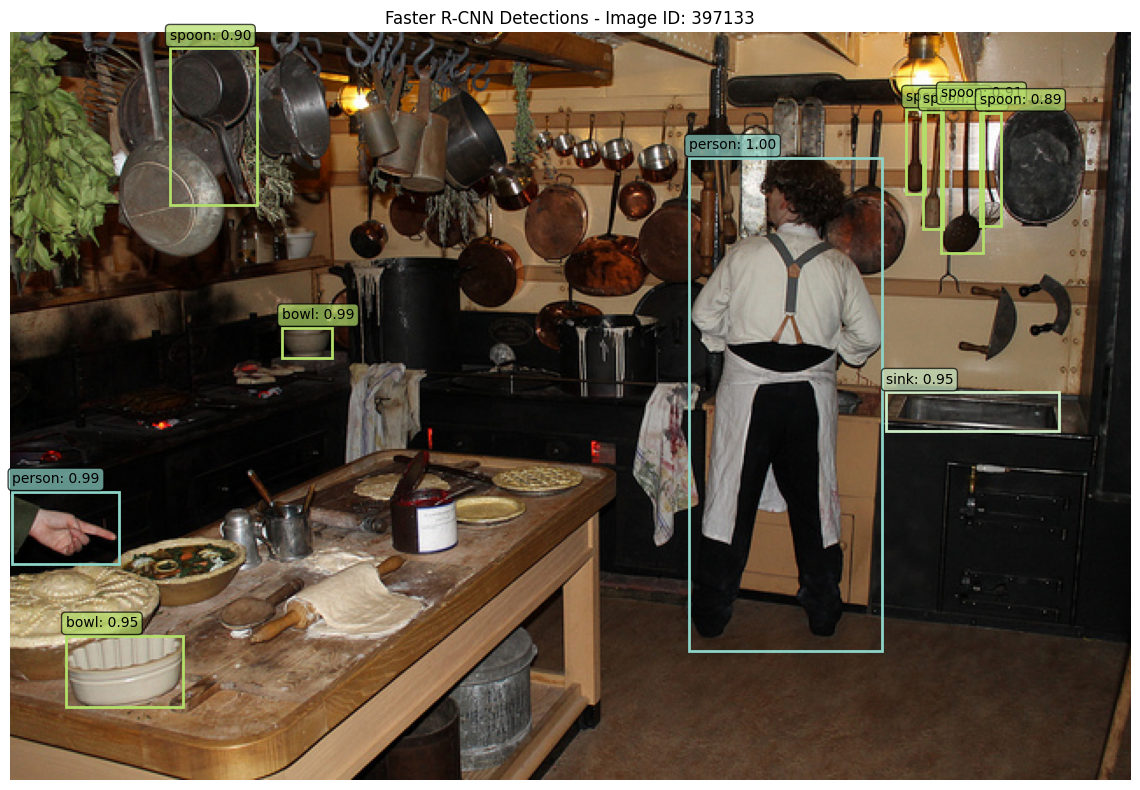


Image 2 (ID: 37777) - 17 detections


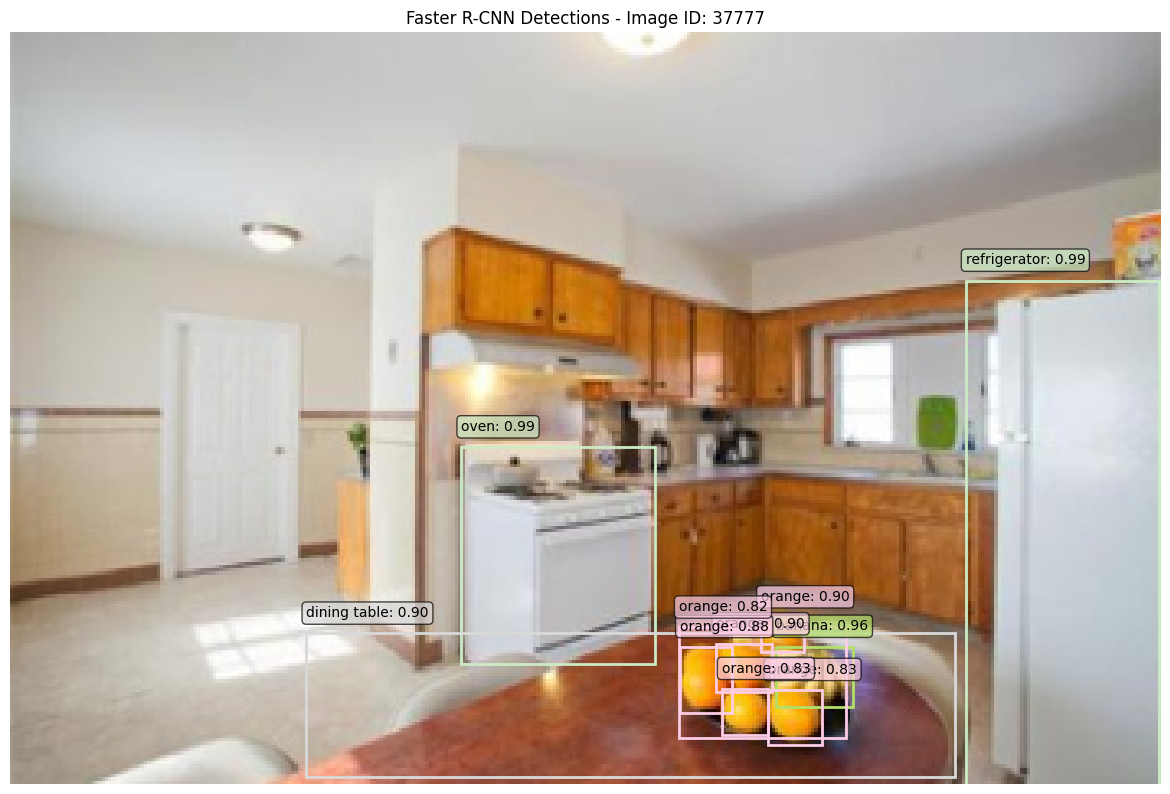


Image 3 (ID: 252219) - 11 detections


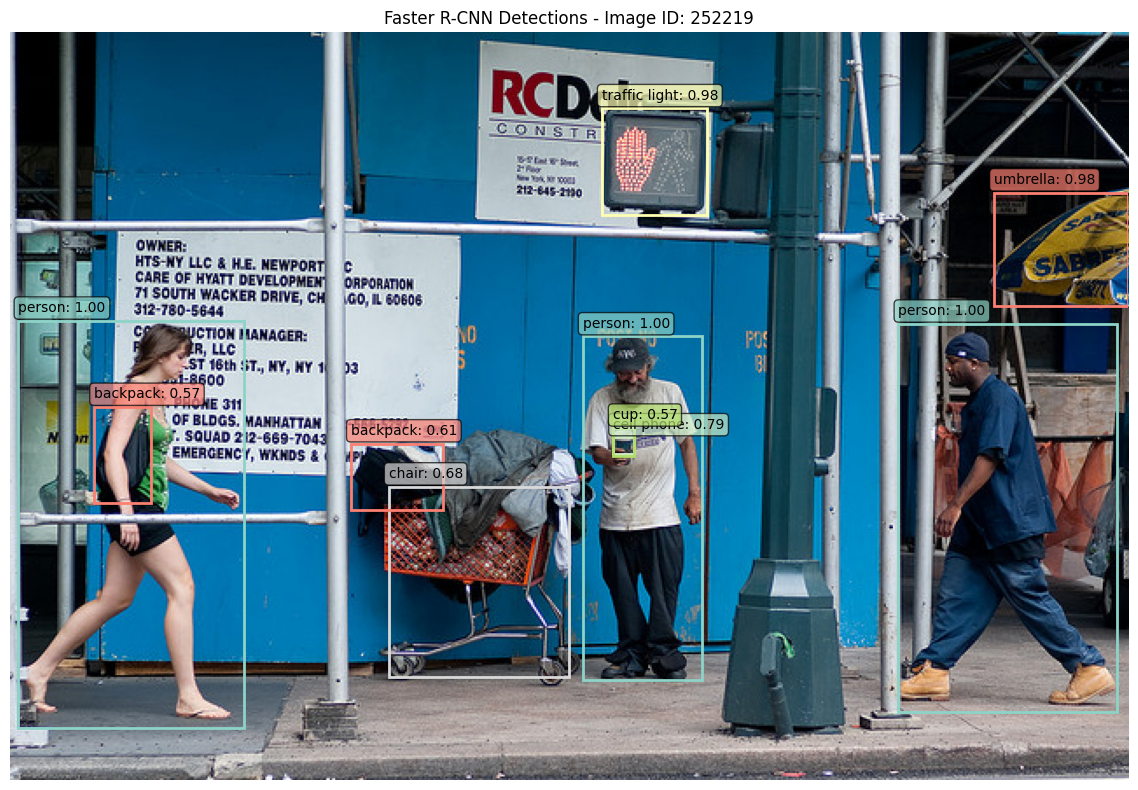


=== Faster R-CNN Evaluation Complete ===
All metrics and visualizations generated successfully!


In [21]:
# COCO Evaluation and Visualization

# Perform COCO evaluation if ground truth annotations are available
def evaluate_with_coco_metrics(results_file, annotation_file):
    """
    Evaluate detection results using COCO metrics
    
    Args:
        results_file: Path to JSON file with detection results
        annotation_file: Path to COCO ground truth annotations
    
    Returns:
        dict: COCO evaluation metrics
    """
    try:
        # Load COCO ground truth
        coco_gt = COCO(annotation_file)
        
        # Load detection results
        coco_dt = coco_gt.loadRes(results_file)
        
        # Create evaluator
        coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
        
        # Restrict evaluation to subset of images if we only processed a subset
        if USE_SUBSET:
            img_ids = list(coco_gt.imgs.keys())[:MAX_IMAGES]
            coco_eval.params.imgIds = img_ids
        
        # Run evaluation
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        
        # Extract metrics
        metrics = {
            'AP_all': coco_eval.stats[0],  # AP @ IoU=0.50:0.95
            'AP_50': coco_eval.stats[1],   # AP @ IoU=0.50
            'AP_75': coco_eval.stats[2],   # AP @ IoU=0.75
            'AP_small': coco_eval.stats[3], # AP for small objects
            'AP_medium': coco_eval.stats[4], # AP for medium objects
            'AP_large': coco_eval.stats[5], # AP for large objects
            'AR_1': coco_eval.stats[6],    # AR @ 1 detection per image
            'AR_10': coco_eval.stats[7],   # AR @ 10 detections per image
            'AR_100': coco_eval.stats[8],  # AR @ 100 detections per image
            'AR_small': coco_eval.stats[9], # AR for small objects
            'AR_medium': coco_eval.stats[10], # AR for medium objects
            'AR_large': coco_eval.stats[11]  # AR for large objects
        }
        
        return metrics
        
    except Exception as e:
        print(f"COCO evaluation failed: {e}")
        return None

# Try to perform COCO evaluation
print("\n=== COCO Evaluation Metrics ===")
annotation_file = "data/coco2017/annotations/instances_val2017.json"
if os.path.exists(annotation_file):
    try:
        coco_metrics = evaluate_with_coco_metrics(results_file, annotation_file)
        if coco_metrics:
            print("COCO Evaluation Results for Faster R-CNN:")
            print(f"Average Precision (AP) @ IoU=0.50:0.95: {coco_metrics['AP_all']:.3f}")
            print(f"Average Precision (AP) @ IoU=0.50: {coco_metrics['AP_50']:.3f}")
            print(f"Average Precision (AP) @ IoU=0.75: {coco_metrics['AP_75']:.3f}")
            print(f"Average Precision (AP) for small objects: {coco_metrics['AP_small']:.3f}")
            print(f"Average Precision (AP) for medium objects: {coco_metrics['AP_medium']:.3f}")
            print(f"Average Precision (AP) for large objects: {coco_metrics['AP_large']:.3f}")
            print(f"Average Recall (AR) @ 100 detections: {coco_metrics['AR_100']:.3f}")
            
            # Add COCO metrics to stored results
            faster_rcnn_metrics.update(coco_metrics)
        else:
            print("COCO evaluation could not be completed")
    except Exception as e:
        print(f"Error during COCO evaluation: {e}")
else:
    print(f"Ground truth annotations not found at: {annotation_file}")
    print("Skipping COCO evaluation")

# Visualize sample detections
def visualize_detections(image_tensor, detections, image_id, max_detections=10):
    """
    Visualize detection results on an image
    
    Args:
        image_tensor: Input image tensor [C, H, W]
        detections: Detection results from model
        image_id: Image ID for title
        max_detections: Maximum number of detections to show
    """
    # Convert tensor to numpy array for visualization
    if isinstance(image_tensor, torch.Tensor):
        # Handle tensor format [C, H, W] -> [H, W, C]
        if image_tensor.dim() == 4:
            image_tensor = image_tensor.squeeze(0)
        
        image_np = image_tensor.permute(1, 2, 0).cpu().numpy()
        
        # Ensure values are in [0, 1] range
        if image_np.max() <= 1.0:
            image_np = (image_np * 255).astype(np.uint8)
        else:
            image_np = image_np.astype(np.uint8)
    else:
        image_np = image_tensor
    
    # Create figure
    plt.figure(figsize=(12, 8))
    plt.imshow(image_np)
    plt.axis('off')
    plt.title(f'Faster R-CNN Detections - Image ID: {image_id}')
    
    # Draw bounding boxes
    boxes = detections['boxes'][:max_detections]
    labels = detections['labels'][:max_detections]
    scores = detections['scores'][:max_detections]
    
    colors = plt.cm.Set3(np.linspace(0, 1, len(COCO_CLASSES)))
    
    for i, (box, label, score) in enumerate(zip(boxes, labels, scores)):
        x1, y1, x2, y2 = box.numpy()
        width = x2 - x1
        height = y2 - y1
        
        # Get class name and color
        class_name = COCO_CLASSES[label] if label < len(COCO_CLASSES) else f'Class_{label}'
        color = colors[label % len(colors)]
        
        # Draw bounding box
        rect = plt.Rectangle((x1, y1), width, height, 
                           linewidth=2, edgecolor=color, facecolor='none')
        plt.gca().add_patch(rect)
        
        # Add label with confidence score
        plt.text(x1, y1 - 5, f'{class_name}: {score:.2f}', 
                bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.7),
                fontsize=10, color='black')
    
    plt.tight_layout()
    plt.show()

# Show sample detections from the first few images
print(f"\n=== Sample Detection Visualizations ===")
print("Showing detection results from first 3 images...")

# Get a few sample images for visualization
sample_indices = [0, 1, 2]  # First 3 images
for idx in sample_indices:
    try:
        # Get image and target
        image, target = dataset_subset[idx]
        image_id = target['image_id'].item()
        
        # Perform inference for visualization
        with torch.no_grad():
            detections = faster_rcnn_inference(faster_rcnn, image, CONFIDENCE_THRESHOLD)
        
        # Visualize
        print(f"\nImage {idx + 1} (ID: {image_id}) - {len(detections['boxes'])} detections")
        visualize_detections(image, detections, image_id)
        
    except Exception as e:
        print(f"Error visualizing image {idx}: {e}")

print(f"\n=== Faster R-CNN Evaluation Complete ===")
print(f"All metrics and visualizations generated successfully!")

## **DinoV3**

### Import DinoV3 Model

In [22]:
# Load DinoV3 model with download progress
# Documentation: https://huggingface.co/facebook/dinov3-vit7b16-pretrain-lvd1689m

print("=== Loading DinoV3 Model ===")
print("Model: facebook/dinov3-vit7b16-pretrain-lvd1689m")

from transformers import AutoImageProcessor, AutoModel
import os

# Enable progress bars for transformers downloads
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = 'True'  # Faster downloads if available

print("\nDownloading DinoV3 Image Processor...")
processor = AutoImageProcessor.from_pretrained(
    "facebook/dinov3-vit7b16-pretrain-lvd1689m",
    use_fast=True,
    trust_remote_code=True
)
print("Image Processor loaded successfully!")

print("\nDownloading DinoV3 Model (this may take a while for first download)...")
model = AutoModel.from_pretrained(
    "facebook/dinov3-vit7b16-pretrain-lvd1689m",
    trust_remote_code=True,
    torch_dtype=torch.float32,  # Explicitly set dtype
    # Don't use device_map="auto" to have manual control
)
print("DinoV3 Model loaded successfully!")

# Move model to the specific device (A6000 on cuda:1) and set to evaluation mode
model = model.to(device)
model.eval()

print(f"\nModel Summary:")
print(f"Device: {next(model.parameters()).device}")
print(f"Model type: {type(model).__name__}")
print(f"Parameters: {sum(p.numel() for p in model.parameters()):,}")
print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")

# Test model with a dummy input to ensure it's working on the correct device
print(f"\nTesting model with dummy input on {device}...")
try:
    with torch.no_grad():
        dummy_input = torch.randn(1, 3, 224, 224).to(device)
        dummy_output = model(dummy_input)
        print(f"Model test successful! Output shape: {dummy_output.last_hidden_state.shape}")
        print(f"Output device: {dummy_output.last_hidden_state.device}")
except Exception as e:
    print(f"Model test failed: {e}")

print(f"\nDinoV3 setup completed successfully!")
print(f"Model and operations will use: {device}")
print(f"Ready for feature extraction and analysis tasks.")


=== Loading DinoV3 Model ===
Model: facebook/dinov3-vit7b16-pretrain-lvd1689m



Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Image Processor loaded successfully!



Loading checkpoint shards:   0%|          | 0/6 [00:00<?, ?it/s]

DinoV3 Model loaded successfully!

Model Summary:
Device: cuda:1
Model type: DINOv3ViTModel
Parameters: 6,716,035,072
Trainable parameters: 6,716,035,072

Testing model with dummy input on cuda:1...
Model test successful! Output shape: torch.Size([1, 201, 4096])
Output device: cuda:1

DinoV3 setup completed successfully!
Model and operations will use: cuda:1
Ready for feature extraction and analysis tasks.

Model Summary:
Device: cuda:1
Model type: DINOv3ViTModel
Parameters: 6,716,035,072
Trainable parameters: 6,716,035,072

Testing model with dummy input on cuda:1...
Model test successful! Output shape: torch.Size([1, 201, 4096])
Output device: cuda:1

DinoV3 setup completed successfully!
Model and operations will use: cuda:1
Ready for feature extraction and analysis tasks.


### Perform Inference and Measure Performance Metrics for DinoV3

In [23]:
# DinoV3 Feature Extraction with Performance Metrics

import time
import psutil
import gc
import json
from collections import defaultdict
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

def get_memory_usage():
    """Get current memory usage in MB"""
    process = psutil.Process()
    return process.memory_info().rss / 1024 / 1024

def get_gpu_memory_usage():
    """Get current GPU memory usage in MB"""
    if torch.cuda.is_available():
        return torch.cuda.memory_allocated() / 1024 / 1024
    return 0

def dinov3_feature_extraction(model, processor, image, patch_features=False):
    """
    Perform feature extraction with DinoV3
    
    Args:
        model: DinoV3 model
        processor: DinoV3 image processor
        image: Input image (PIL Image or tensor)
        patch_features: If True, return patch-level features; if False, return CLS token
    
    Returns:
        dict: Feature extraction results
    """
    # Process image
    if isinstance(image, torch.Tensor):
        # Convert tensor back to PIL for processor
        if image.dim() == 4:
            image = image.squeeze(0)
        # Convert from [C, H, W] to [H, W, C] and to PIL
        image_np = image.permute(1, 2, 0).cpu().numpy()
        if image_np.max() <= 1.0:
            image_np = (image_np * 255).astype(np.uint8)
        image = PIL.Image.fromarray(image_np)
    
    # Process image with DinoV3 processor
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Feature extraction
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Extract features
    last_hidden_states = outputs.last_hidden_state  # Shape: [batch_size, num_patches + 1, hidden_size]
    
    # CLS token is the first token (global representation)
    cls_features = last_hidden_states[:, 0, :].cpu()  # Shape: [batch_size, hidden_size]
    
    # Patch features (excluding CLS token)
    patch_features_tensor = last_hidden_states[:, 1:, :].cpu()  # Shape: [batch_size, num_patches, hidden_size]
    
    results = {
        'cls_features': cls_features,
        'patch_features': patch_features_tensor if patch_features else None,
        'feature_dim': cls_features.shape[-1],
        'num_patches': patch_features_tensor.shape[1] if patch_features else None
    }
    
    return results

def compute_feature_statistics(features_list):
    """
    Compute statistics for extracted features
    
    Args:
        features_list: List of feature tensors
    
    Returns:
        dict: Feature statistics
    """
    if not features_list:
        return {}
    
    # Stack all features
    all_features = torch.cat(features_list, dim=0)  # [num_images, feature_dim]
    
    # Compute statistics
    feature_mean = torch.mean(all_features, dim=0)
    feature_std = torch.std(all_features, dim=0)
    feature_norm = torch.norm(all_features, dim=1)
    
    # Compute pairwise cosine similarities for a subset (to avoid memory issues)
    max_samples = min(100, len(all_features))
    subset_features = all_features[:max_samples].numpy()
    cosine_sim_matrix = cosine_similarity(subset_features)
    
    # Remove diagonal (self-similarity)
    mask = ~np.eye(cosine_sim_matrix.shape[0], dtype=bool)
    cosine_similarities = cosine_sim_matrix[mask]
    
    stats = {
        'mean_feature_norm': torch.mean(feature_norm).item(),
        'std_feature_norm': torch.std(feature_norm).item(),
        'min_feature_norm': torch.min(feature_norm).item(),
        'max_feature_norm': torch.max(feature_norm).item(),
        'feature_dimensionality': all_features.shape[1],
        'mean_cosine_similarity': np.mean(cosine_similarities),
        'std_cosine_similarity': np.std(cosine_similarities),
        'min_cosine_similarity': np.min(cosine_similarities),
        'max_cosine_similarity': np.max(cosine_similarities)
    }
    
    return stats

# Initialize performance tracking
print("=== DinoV3 Feature Extraction and Performance Evaluation ===\n")

# Set up evaluation parameters
MAX_IMAGES = 100  # Limit for faster evaluation during development
USE_SUBSET = True  # Set to False to evaluate on full validation set
EXTRACT_PATCH_FEATURES = False  # Set to True to extract patch-level features (memory intensive)

# Performance metrics storage
inference_times = []
memory_usage_before = []
memory_usage_after = []
gpu_memory_before = []
gpu_memory_after = []
cls_features_list = []
feature_extraction_results = []

# Track overall timing
overall_start_time = time.time()

print(f"Starting feature extraction on {'subset of' if USE_SUBSET else 'full'} COCO validation set...")
print(f"Device: {device}")
print(f"Extract patch features: {EXTRACT_PATCH_FEATURES}")
print(f"Initial CPU Memory: {get_memory_usage():.2f} MB")
print(f"Initial GPU Memory: {get_gpu_memory_usage():.2f} MB")
print()

# Ensure model is in evaluation mode and on correct device
model.eval()
model = model.to(device)

# Verify model is on the correct device
print(f"Model device verification: {next(model.parameters()).device}")
if str(next(model.parameters()).device) != str(device):
    print(f"WARNING: Model is not on expected device {device}")
    print(f"Moving model to {device}...")
    model = model.to(device)
else:
    print(f"✓ Model confirmed on {device}")

# Memory check before starting inference
if torch.cuda.is_available():
    torch.cuda.empty_cache()  # Clear cache to get accurate memory reading
    print(f"GPU Memory after model placement: {get_gpu_memory_usage():.2f} MB")

# Create a subset of the dataset for faster evaluation
dataset_subset = coco_dataset if not USE_SUBSET else torch.utils.data.Subset(
    coco_dataset, range(min(MAX_IMAGES, len(coco_dataset)))
)

# Create DataLoader for the subset
subset_dataloader = DataLoader(
    dataset_subset,
    batch_size=1,
    shuffle=False,
    num_workers=0,
    collate_fn=collate_fn,
    pin_memory=True if torch.cuda.is_available() else False
)

print(f"Processing {len(dataset_subset)} images...")

# Perform feature extraction on dataset
for batch_idx, batch in enumerate(tqdm(subset_dataloader, desc="DinoV3 Feature Extraction")):
    image, target = batch[0]  # Extract from batch list
    image_id = target['image_id'].item()
    
    # Record memory usage before inference
    mem_before = get_memory_usage()
    gpu_mem_before = get_gpu_memory_usage()
    memory_usage_before.append(mem_before)
    gpu_memory_before.append(gpu_mem_before)
    
    # Time the feature extraction
    start_time = time.time()
    
    # Perform feature extraction
    features = dinov3_feature_extraction(model, processor, image, EXTRACT_PATCH_FEATURES)
    
    # Record inference time
    inference_time = time.time() - start_time
    inference_times.append(inference_time)
    
    # Record memory usage after inference
    mem_after = get_memory_usage()
    gpu_mem_after = get_gpu_memory_usage()
    memory_usage_after.append(mem_after)
    gpu_memory_after.append(gpu_mem_after)
    
    # Store features
    cls_features_list.append(features['cls_features'])
    
    # Store result summary
    feature_extraction_results.append({
        'image_id': image_id,
        'feature_dim': features['feature_dim'],
        'num_patches': features['num_patches'],
        'cls_feature_norm': torch.norm(features['cls_features'].squeeze()).item(),
        'inference_time': inference_time
    })
    
    # Print progress every 10 images
    if (batch_idx + 1) % 10 == 0:
        avg_time = np.mean(inference_times[-10:])
        print(f"Processed {batch_idx + 1} images, avg time (last 10): {avg_time:.3f}s")

# Calculate overall timing
total_inference_time = time.time() - overall_start_time

# Compute feature statistics
print("\nComputing feature statistics...")
feature_stats = compute_feature_statistics(cls_features_list)

print(f"\n=== DinoV3 Performance Metrics ===")
print(f"Dataset: COCO 2017 Validation ({'subset' if USE_SUBSET else 'full'})")
print(f"Images processed: {len(dataset_subset)}")
print(f"Feature extraction mode: {'CLS + Patch features' if EXTRACT_PATCH_FEATURES else 'CLS features only'}")

# Timing metrics
print(f"\n--- Timing Metrics ---")
print(f"Total feature extraction time: {total_inference_time:.2f} seconds")
print(f"Average time per image: {np.mean(inference_times):.3f} ± {np.std(inference_times):.3f} seconds")
print(f"Fastest extraction: {np.min(inference_times):.3f} seconds")
print(f"Slowest extraction: {np.max(inference_times):.3f} seconds")
print(f"Images per second: {len(dataset_subset) / total_inference_time:.2f}")

# Memory metrics
print(f"\n--- Memory Usage Metrics ---")
print(f"Average CPU memory during extraction: {np.mean(memory_usage_after):.2f} MB")
print(f"Peak CPU memory usage: {np.max(memory_usage_after):.2f} MB")
print(f"Average CPU memory increase per extraction: {np.mean(np.array(memory_usage_after) - np.array(memory_usage_before)):.2f} MB")

if torch.cuda.is_available():
    print(f"Average GPU memory during extraction: {np.mean(gpu_memory_after):.2f} MB")
    print(f"Peak GPU memory usage: {np.max(gpu_memory_after):.2f} MB")
    print(f"Average GPU memory increase per extraction: {np.mean(np.array(gpu_memory_after) - np.array(gpu_memory_before)):.2f} MB")

# Feature statistics
print(f"\n--- Feature Statistics ---")
if feature_stats:
    print(f"Feature dimensionality: {feature_stats['feature_dimensionality']}")
    print(f"Mean feature norm: {feature_stats['mean_feature_norm']:.3f} ± {feature_stats['std_feature_norm']:.3f}")
    print(f"Feature norm range: {feature_stats['min_feature_norm']:.3f} - {feature_stats['max_feature_norm']:.3f}")
    print(f"Mean cosine similarity between features: {feature_stats['mean_cosine_similarity']:.3f} ± {feature_stats['std_cosine_similarity']:.3f}")
    print(f"Cosine similarity range: {feature_stats['min_cosine_similarity']:.3f} - {feature_stats['max_cosine_similarity']:.3f}")

# Save results
results_file = f"logs/dinov3_features_{len(dataset_subset)}_images.json"
with open(results_file, 'w') as f:
    json.dump(feature_extraction_results, f, indent=2)
print(f"\nFeature extraction results saved to: {results_file}")

# Save features as numpy arrays for future use
features_file = f"logs/dinov3_cls_features_{len(dataset_subset)}_images.npy"
all_cls_features = torch.cat(cls_features_list, dim=0).numpy()
np.save(features_file, all_cls_features)
print(f"CLS features saved to: {features_file}")

# Store results for comparison with other models
dinov3_metrics = {
    'model_name': 'DinoV3',
    'total_images': len(dataset_subset),
    'total_inference_time': total_inference_time,
    'avg_time_per_image': np.mean(inference_times),
    'std_time_per_image': np.std(inference_times),
    'images_per_second': len(dataset_subset) / total_inference_time,
    'avg_cpu_memory': np.mean(memory_usage_after),
    'peak_cpu_memory': np.max(memory_usage_after),
    'avg_gpu_memory': np.mean(gpu_memory_after) if torch.cuda.is_available() else 0,
    'peak_gpu_memory': np.max(gpu_memory_after) if torch.cuda.is_available() else 0,
    'feature_dimensionality': feature_stats.get('feature_dimensionality', 0),
    'mean_feature_norm': feature_stats.get('mean_feature_norm', 0),
    'mean_cosine_similarity': feature_stats.get('mean_cosine_similarity', 0),
    'extract_patch_features': EXTRACT_PATCH_FEATURES
}

# Add feature statistics to metrics
dinov3_metrics.update(feature_stats)

print(f"\n=== Summary for DinoV3 ===")
print(f"✓ Processed {len(dataset_subset)} images in {total_inference_time:.2f} seconds")
print(f"✓ Average extraction speed: {len(dataset_subset) / total_inference_time:.2f} images/second")
print(f"✓ Feature dimensionality: {feature_stats.get('feature_dimensionality', 'N/A')}")
print(f"✓ Mean feature norm: {feature_stats.get('mean_feature_norm', 0):.3f}")
print(f"✓ Results and features saved")

# Clean up GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print(f"\n✓ DinoV3 feature extraction completed successfully!")
print(f"Note: DinoV3 extracts features for representation learning, not direct object detection.")
print(f"Features can be used for downstream tasks like classification, retrieval, or clustering.")

=== DinoV3 Feature Extraction and Performance Evaluation ===

Starting feature extraction on subset of COCO validation set...
Device: cuda:1
Extract patch features: False
Initial CPU Memory: 2567.74 MB
Initial GPU Memory: 0.00 MB

Model device verification: cuda:1
✓ Model confirmed on cuda:1
GPU Memory after model placement: 0.00 MB
Processing 100 images...


DinoV3 Feature Extraction:   0%|          | 0/100 [00:00<?, ?it/s]

Processed 10 images, avg time (last 10): 0.212s
Processed 20 images, avg time (last 10): 0.209s
Processed 20 images, avg time (last 10): 0.209s
Processed 30 images, avg time (last 10): 0.207s
Processed 30 images, avg time (last 10): 0.207s
Processed 40 images, avg time (last 10): 0.208s
Processed 40 images, avg time (last 10): 0.208s
Processed 50 images, avg time (last 10): 0.208s
Processed 50 images, avg time (last 10): 0.208s
Processed 60 images, avg time (last 10): 0.209s
Processed 60 images, avg time (last 10): 0.209s
Processed 70 images, avg time (last 10): 0.208s
Processed 70 images, avg time (last 10): 0.208s
Processed 80 images, avg time (last 10): 0.208s
Processed 80 images, avg time (last 10): 0.208s
Processed 90 images, avg time (last 10): 0.209s
Processed 90 images, avg time (last 10): 0.209s
Processed 100 images, avg time (last 10): 0.211s

Computing feature statistics...

=== DinoV3 Performance Metrics ===
Dataset: COCO 2017 Validation (subset)
Images processed: 100
Featu

=== DinoV3 Feature Analysis and Visualization ===

1. Feature Distribution Analysis:


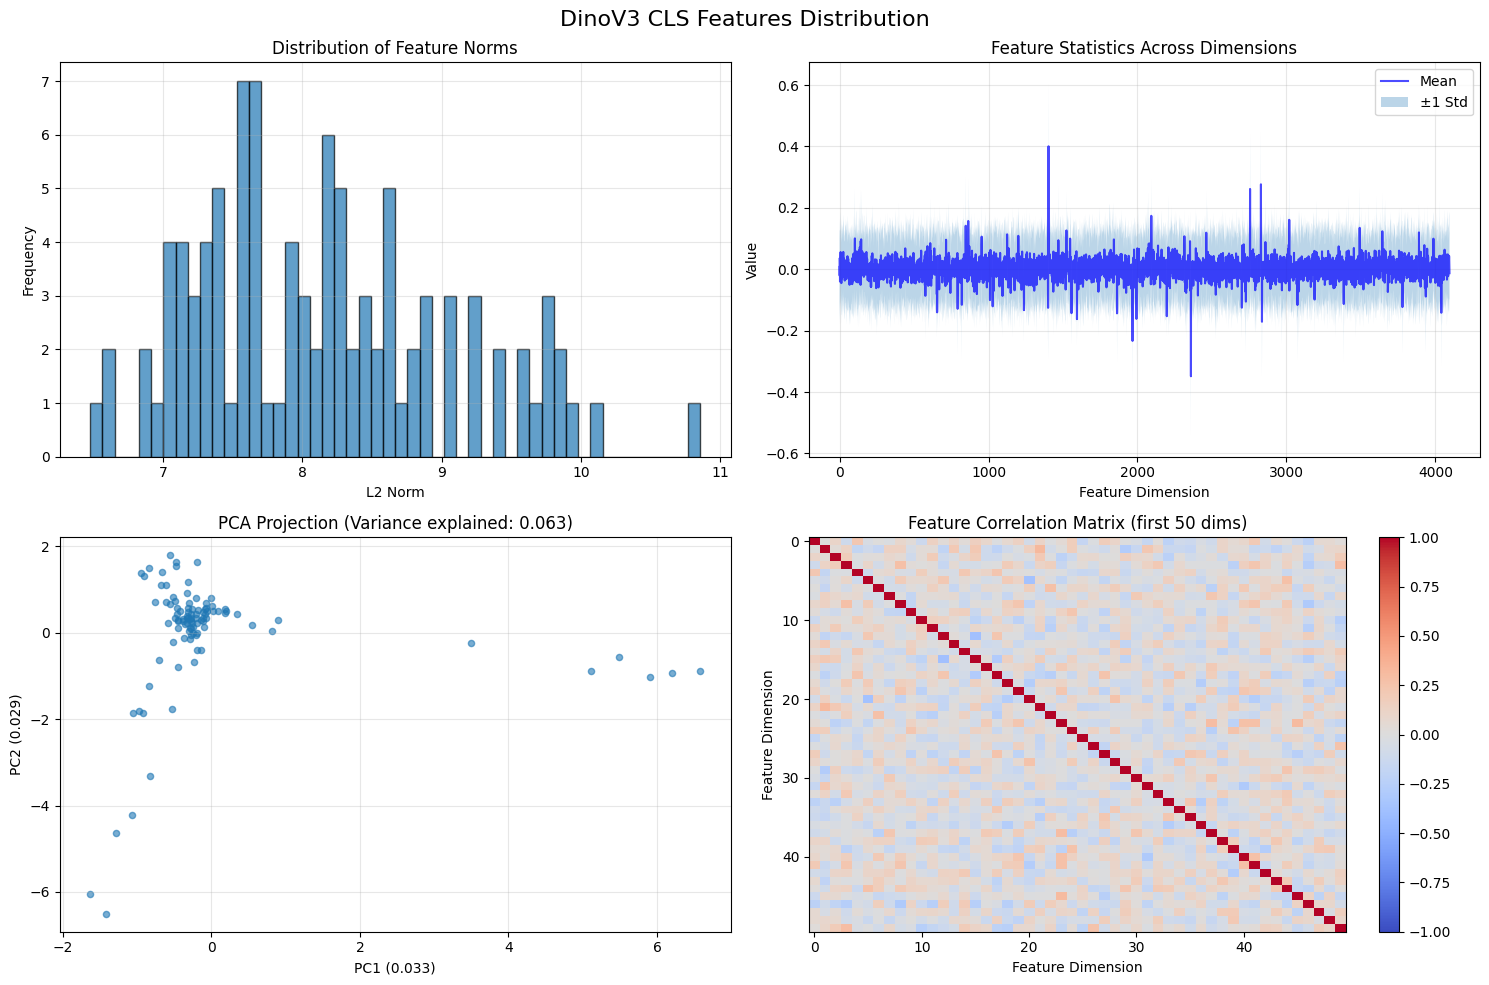


2. Sample Images with Feature Statistics:


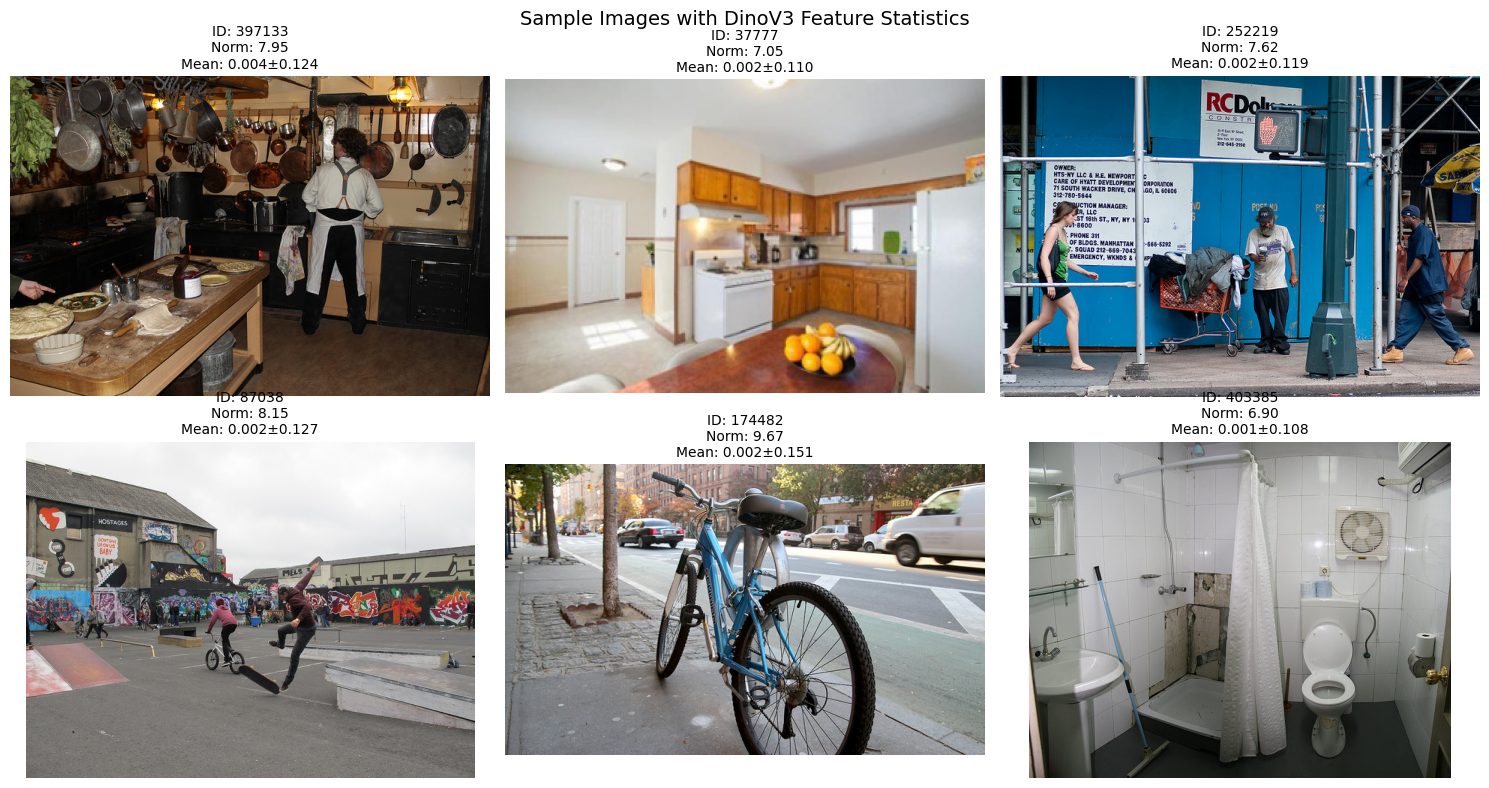


3. Image Similarity Analysis:
Finding images most similar to the first image based on DinoV3 features...


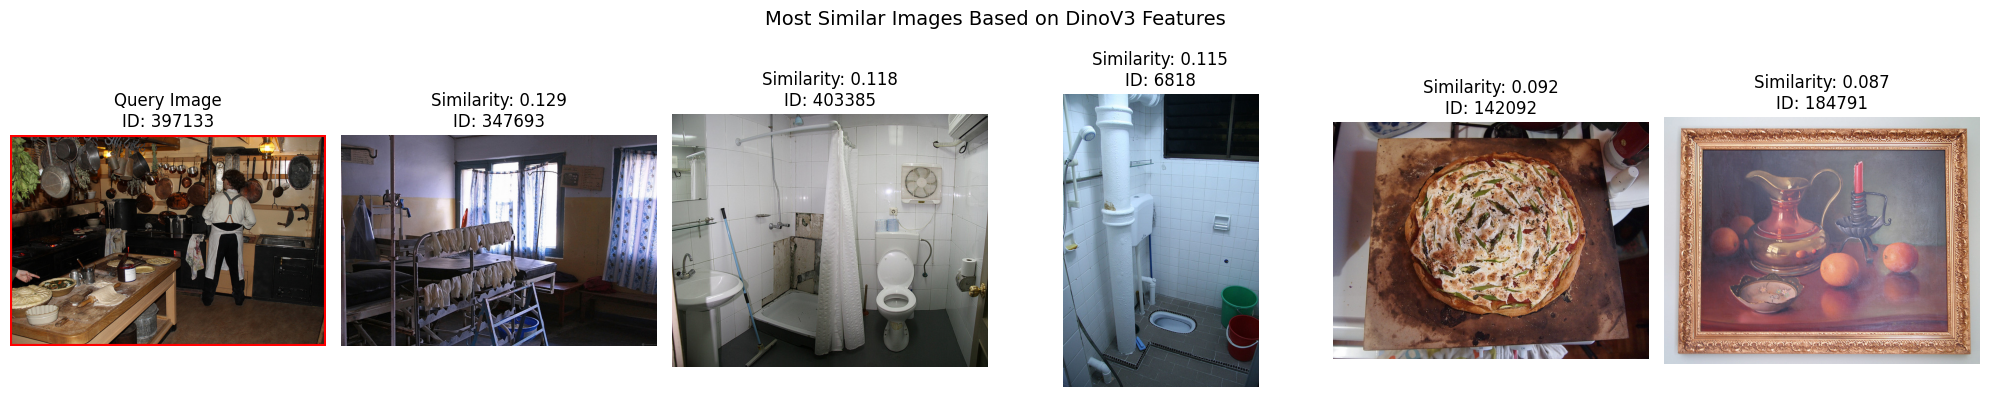

Top 5 most similar images:
  1. Image ID 347693: Similarity = 0.129
  2. Image ID 403385: Similarity = 0.118
  3. Image ID 6818: Similarity = 0.115
  4. Image ID 142092: Similarity = 0.092
  5. Image ID 184791: Similarity = 0.087

4. Advanced Feature Visualization:
Creating t-SNE visualization of features...


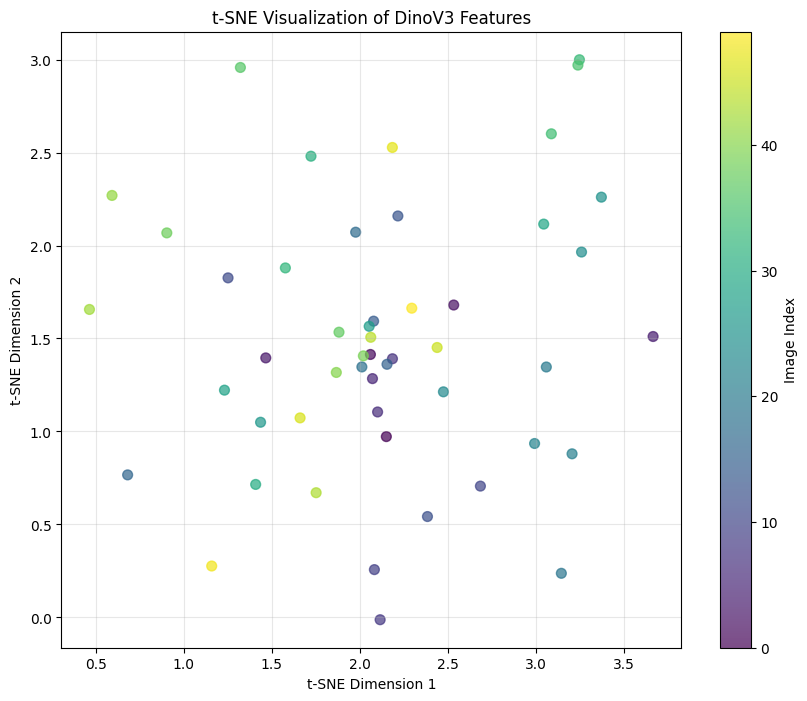

t-SNE plot shows the 2D embedding of 50 image features

=== DinoV3 Analysis Complete ===
✓ Feature distributions analyzed
✓ Sample visualizations created
✓ Image similarity computed
✓ Advanced visualizations generated

DinoV3 features capture rich semantic representations useful for:
  - Image retrieval and similarity search
  - Transfer learning for downstream tasks
  - Clustering and unsupervised analysis
  - Feature-based image classification


In [24]:
# DinoV3 Feature Analysis and Visualization

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_feature_distribution(features, title="Feature Distribution"):
    """
    Visualize the distribution of features
    
    Args:
        features: Feature tensor [num_samples, feature_dim]
        title: Plot title
    """
    # Compute feature norms
    feature_norms = torch.norm(features, dim=1).numpy()
    
    # Create subplots
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(title, fontsize=16)
    
    # Feature norm distribution
    axes[0, 0].hist(feature_norms, bins=50, alpha=0.7, edgecolor='black')
    axes[0, 0].set_title('Distribution of Feature Norms')
    axes[0, 0].set_xlabel('L2 Norm')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Feature dimension statistics
    feature_means = torch.mean(features, dim=0).numpy()
    feature_stds = torch.std(features, dim=0).numpy()
    
    dim_indices = np.arange(len(feature_means))
    axes[0, 1].plot(dim_indices, feature_means, 'b-', alpha=0.7, label='Mean')
    axes[0, 1].fill_between(dim_indices, feature_means - feature_stds, 
                           feature_means + feature_stds, alpha=0.3, label='±1 Std')
    axes[0, 1].set_title('Feature Statistics Across Dimensions')
    axes[0, 1].set_xlabel('Feature Dimension')
    axes[0, 1].set_ylabel('Value')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3)
    
    # PCA analysis (2D projection)
    if features.shape[0] > 1:
        pca = PCA(n_components=2)
        features_pca = pca.fit_transform(features.numpy())
        
        axes[1, 0].scatter(features_pca[:, 0], features_pca[:, 1], alpha=0.6, s=20)
        axes[1, 0].set_title(f'PCA Projection (Variance explained: {pca.explained_variance_ratio_.sum():.3f})')
        axes[1, 0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.3f})')
        axes[1, 0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.3f})')
        axes[1, 0].grid(True, alpha=0.3)
    else:
        axes[1, 0].text(0.5, 0.5, 'Need >1 sample for PCA', ha='center', va='center')
        axes[1, 0].set_title('PCA Projection')
    
    # Correlation heatmap (subset of dimensions)
    max_dims = min(50, features.shape[1])
    if features.shape[0] > 1:
        corr_matrix = np.corrcoef(features[:, :max_dims].numpy().T)
        im = axes[1, 1].imshow(corr_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
        axes[1, 1].set_title(f'Feature Correlation Matrix (first {max_dims} dims)')
        axes[1, 1].set_xlabel('Feature Dimension')
        axes[1, 1].set_ylabel('Feature Dimension')
        plt.colorbar(im, ax=axes[1, 1])
    else:
        axes[1, 1].text(0.5, 0.5, 'Need >1 sample for correlation', ha='center', va='center')
        axes[1, 1].set_title('Feature Correlation Matrix')
    
    plt.tight_layout()
    plt.show()

def visualize_sample_images_with_features(dataset_subset, features_list, num_samples=6):
    """
    Visualize sample images with their feature statistics
    
    Args:
        dataset_subset: Dataset subset
        features_list: List of extracted features
        num_samples: Number of samples to show
    """
    fig, axes = plt.subplots(2, num_samples//2, figsize=(15, 8))
    axes = axes.flatten()
    
    for i in range(min(num_samples, len(dataset_subset))):
        # Get image and features
        image, target = dataset_subset[i]
        features = features_list[i]
        image_id = target['image_id'].item()
        
        # Convert tensor to numpy for visualization
        if isinstance(image, torch.Tensor):
            if image.dim() == 4:
                image = image.squeeze(0)
            image_np = image.permute(1, 2, 0).cpu().numpy()
            if image_np.max() <= 1.0:
                image_np = (image_np * 255).astype(np.uint8)
        
        # Display image
        axes[i].imshow(image_np)
        axes[i].axis('off')
        
        # Add feature statistics as title
        feature_norm = torch.norm(features.squeeze()).item()
        feature_mean = torch.mean(features.squeeze()).item()
        feature_std = torch.std(features.squeeze()).item()
        
        title = f'ID: {image_id}\nNorm: {feature_norm:.2f}\nMean: {feature_mean:.3f}±{feature_std:.3f}'
        axes[i].set_title(title, fontsize=10)
    
    plt.suptitle('Sample Images with DinoV3 Feature Statistics', fontsize=14)
    plt.tight_layout()
    plt.show()

def find_similar_images(features_list, dataset_subset, query_idx=0, top_k=5):
    """
    Find most similar images based on feature similarity
    
    Args:
        features_list: List of extracted features
        dataset_subset: Dataset subset
        query_idx: Index of query image
        top_k: Number of similar images to return
    """
    if query_idx >= len(features_list):
        print(f"Query index {query_idx} out of range")
        return
    
    # Get query features
    query_features = features_list[query_idx]
    
    # Compute similarities with all other images
    similarities = []
    for i, features in enumerate(features_list):
        if i != query_idx:
            similarity = torch.cosine_similarity(query_features.squeeze(), features.squeeze(), dim=0).item()
            similarities.append((i, similarity))
    
    # Sort by similarity
    similarities.sort(key=lambda x: x[1], reverse=True)
    
    # Visualize results
    fig, axes = plt.subplots(1, top_k + 1, figsize=(20, 4))
    
    # Show query image
    query_image, query_target = dataset_subset[query_idx]
    if isinstance(query_image, torch.Tensor):
        if query_image.dim() == 4:
            query_image = query_image.squeeze(0)
        query_image_np = query_image.permute(1, 2, 0).cpu().numpy()
        if query_image_np.max() <= 1.0:
            query_image_np = (query_image_np * 255).astype(np.uint8)
    
    axes[0].imshow(query_image_np)
    axes[0].set_title(f'Query Image\nID: {query_target["image_id"].item()}')
    axes[0].axis('off')
    axes[0].add_patch(plt.Rectangle((0, 0), query_image_np.shape[1]-1, 
                                   query_image_np.shape[0]-1, fill=False, 
                                   edgecolor='red', linewidth=3))
    
    # Show similar images
    for i, (img_idx, similarity) in enumerate(similarities[:top_k]):
        image, target = dataset_subset[img_idx]
        if isinstance(image, torch.Tensor):
            if image.dim() == 4:
                image = image.squeeze(0)
            image_np = image.permute(1, 2, 0).cpu().numpy()
            if image_np.max() <= 1.0:
                image_np = (image_np * 255).astype(np.uint8)
        
        axes[i + 1].imshow(image_np)
        axes[i + 1].set_title(f'Similarity: {similarity:.3f}\nID: {target["image_id"].item()}')
        axes[i + 1].axis('off')
    
    plt.suptitle('Most Similar Images Based on DinoV3 Features', fontsize=14)
    plt.tight_layout()
    plt.show()
    
    return similarities[:top_k]

# Perform feature analysis and visualization
print("=== DinoV3 Feature Analysis and Visualization ===\n")

# Visualize feature distributions
print("1. Feature Distribution Analysis:")
all_cls_features = torch.cat(cls_features_list, dim=0)
visualize_feature_distribution(all_cls_features, "DinoV3 CLS Features Distribution")

# Visualize sample images with features
print("\n2. Sample Images with Feature Statistics:")
visualize_sample_images_with_features(dataset_subset, cls_features_list, num_samples=6)

# Find similar images
print("\n3. Image Similarity Analysis:")
if len(cls_features_list) > 5:
    print("Finding images most similar to the first image based on DinoV3 features...")
    similar_images = find_similar_images(cls_features_list, dataset_subset, query_idx=0, top_k=5)
    print("Top 5 most similar images:")
    for i, (img_idx, similarity) in enumerate(similar_images):
        image, target = dataset_subset[img_idx]
        print(f"  {i+1}. Image ID {target['image_id'].item()}: Similarity = {similarity:.3f}")
else:
    print("Need more images for similarity analysis")

# Advanced analysis: t-SNE visualization if enough samples
print("\n4. Advanced Feature Visualization:")
if len(cls_features_list) >= 10:
    print("Creating t-SNE visualization of features...")
    
    # Subsample for t-SNE (it's computationally expensive)
    max_samples_tsne = min(50, len(cls_features_list))
    features_subset = all_cls_features[:max_samples_tsne].numpy()
    
    # Apply t-SNE
    tsne = TSNE(n_components=2, random_state=42, perplexity=min(30, max_samples_tsne-1))
    features_tsne = tsne.fit_transform(features_subset)
    
    # Plot t-SNE
    plt.figure(figsize=(10, 8))
    scatter = plt.scatter(features_tsne[:, 0], features_tsne[:, 1], 
                         alpha=0.7, s=50, c=range(len(features_tsne)), cmap='viridis')
    plt.title('t-SNE Visualization of DinoV3 Features')
    plt.xlabel('t-SNE Dimension 1')
    plt.ylabel('t-SNE Dimension 2')
    plt.colorbar(scatter, label='Image Index')
    plt.grid(True, alpha=0.3)
    plt.show()
    
    print(f"t-SNE plot shows the 2D embedding of {max_samples_tsne} image features")
else:
    print("Need at least 10 samples for t-SNE visualization")

print("\n=== DinoV3 Analysis Complete ===")
print("✓ Feature distributions analyzed")
print("✓ Sample visualizations created") 
print("✓ Image similarity computed")
print("✓ Advanced visualizations generated")
print("\nDinoV3 features capture rich semantic representations useful for:")
print("  - Image retrieval and similarity search")
print("  - Transfer learning for downstream tasks")
print("  - Clustering and unsupervised analysis")
print("  - Feature-based image classification")

## **DETR**

### Import DETR Model

In [5]:
# Load model directly
# Documentation: https://huggingface.co/facebook/detr-resnet-50

print("=== Loading DETR Model ===")
print("Model: facebook/detr-resnet-50")

from transformers import AutoImageProcessor, AutoModelForObjectDetection

# Enable progress bars for transformers downloads
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = 'True'  # Faster downloads if available

print("\nDownloading DETR Image Processor...")

processor = AutoImageProcessor.from_pretrained("facebook/detr-resnet-50",
                                                   use_fast=True,
                                                   trust_remote_code=True)
model = AutoModelForObjectDetection.from_pretrained("facebook/detr-resnet-50",
                                                        trust_remote_code=True,
                                                        torch_dtype=torch.float32,  # Explicitly set dtype,
                                            
                                                        )

=== Loading DETR Model ===
Model: facebook/detr-resnet-50



Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/torch/nn/modules/module.py:2441: UserWarning: for conv1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.weight: copying from a non-meta parameter in the checkpoint to a meta parameter in the current model, which is a no-op. (Did you mean to pass `assign=True` to assign items in the state dictionary to their corresponding key in the module instead of copying them in place?)
  warnings.warn(
/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/torch/nn/modules/module.py:2441: UserWarning: for bn1.bias: copying from a non-meta parame

### Perform Inference and Measure Performance Metrics for DETR

In [18]:
# DETR Inference with Performance Metrics on COCO 2017 Dataset



def convert_numpy_types(obj):
    """Convert numpy types to Python native types for JSON serialization"""
    if isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    elif isinstance(obj, dict):
        return {key: convert_numpy_types(value) for key, value in obj.items()}
    elif isinstance(obj, list):
        return [convert_numpy_types(item) for item in obj]
    else:
        return obj

# Load DETR model and processor (use specific variable names to avoid conflicts)
print("=== Loading DETR Model for Inference ===")
from transformers import AutoImageProcessor, AutoModelForObjectDetection

detr_processor = AutoImageProcessor.from_pretrained("facebook/detr-resnet-50")
detr_model = AutoModelForObjectDetection.from_pretrained("facebook/detr-resnet-50")

# Move DETR model to device
detr_model = detr_model.to(device).eval()
print(f"DETR model loaded and moved to {device}")

def detr_inference(model, processor, image, confidence_threshold=0.7):
    """
    Perform object detection inference with DETR
    
    Args:
        model: DETR model
        processor: DETR processor
        image: Input image tensor [C, H, W]
        confidence_threshold: Minimum confidence for detections
    
    Returns:
        dict: Detection results with boxes, scores, and labels
    """
    # Ensure image has batch dimension
    if image.dim() == 3:
        image = image.unsqueeze(0)  # [1, C, H, W]
    
    # Move to device
    image = image.to(device)
    
    # Process with DETR processor
    inputs = processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Inference
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Post-process results
    # Get target image sizes (height, width) for post-processing
    target_sizes = torch.tensor([image.shape[-2:]]).to(device)  # [height, width]
    
    # Post-process to get final detections
    results = processor.post_process_object_detection(
        outputs, 
        target_sizes=target_sizes, 
        threshold=confidence_threshold
    )[0]
    
    return results

def convert_detr_to_coco_format(image_id, detections):
    """
    Convert DETR detections to COCO format
    
    Args:
        image_id: COCO image ID
        detections: DETR detection results
    
    Returns:
        list: Detections in COCO format
    """
    coco_results = []
    
    if 'boxes' not in detections or len(detections['boxes']) == 0:
        return coco_results
    
    boxes = detections['boxes']
    scores = detections['scores']
    labels = detections['labels']
    
    for i in range(len(boxes)):
        # Convert box format from [x1, y1, x2, y2] to [x, y, width, height]
        x1, y1, x2, y2 = boxes[i].tolist()
        width = x2 - x1
        height = y2 - y1
        
        coco_results.append({
            'image_id': int(image_id),
            'category_id': int(labels[i].item()),
            'bbox': [float(x1), float(y1), float(width), float(height)],
            'score': float(scores[i].item())
        })
    
    return coco_results

# Initialize performance tracking
print("=== DETR Inference and Performance Evaluation ===\\n")

# Set up evaluation parameters
CONFIDENCE_THRESHOLD = 0.7  # DETR confidence threshold
MAX_IMAGES = 100  # Limit for faster evaluation
USE_SUBSET = True  # Set to False to evaluate on full validation set

# Create subset dataset
if USE_SUBSET:
    dataset_subset = torch.utils.data.Subset(coco_dataset, range(min(MAX_IMAGES, len(coco_dataset))))
    subset_dataloader = torch.utils.data.DataLoader(
        dataset_subset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
        pin_memory=True if torch.cuda.is_available() else False
    )
else:
    dataset_subset = coco_dataset
    subset_dataloader = inference_dataloader

print(f"Processing {len(dataset_subset)} images from COCO validation set")

# Performance metrics storage
inference_times = []
memory_usage_before = []
memory_usage_after = []
gpu_memory_before = []
gpu_memory_after = []
total_detections = 0
coco_results = []

# Track overall timing
overall_start_time = time.time()

print(f"\\nStarting inference on {'subset of' if USE_SUBSET else 'full'} COCO validation set...")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"Device: {device}")
print(f"Initial CPU Memory: {get_memory_usage():.2f} MB")
print(f"Initial GPU Memory: {get_gpu_memory_usage():.2f} MB")
print()

# Ensure model is in evaluation mode and on correct device
detr_model.eval()
print(f"DETR model device verification: {next(detr_model.parameters()).device}")

# Process images
for batch_idx, batch in enumerate(tqdm(subset_dataloader, desc="DETR Inference")):
    image, target = batch[0]  # Extract from batch list
    image_id = target['image_id'].item()
    
    # Record memory usage before inference
    mem_before = get_memory_usage()
    gpu_mem_before = get_gpu_memory_usage()
    memory_usage_before.append(mem_before)
    gpu_memory_before.append(gpu_mem_before)
    
    # Time the inference
    start_time = time.time()
    
    # Perform inference with proper DETR variables
    detections = detr_inference(detr_model, detr_processor, image, CONFIDENCE_THRESHOLD)
    
    # Record inference time
    inference_time = time.time() - start_time
    inference_times.append(inference_time)
    
    # Record memory usage after inference
    mem_after = get_memory_usage()
    gpu_mem_after = get_gpu_memory_usage()
    memory_usage_after.append(mem_after)
    gpu_memory_after.append(gpu_mem_after)
    
    # Convert to COCO format for evaluation
    coco_detections = convert_detr_to_coco_format(image_id, detections)
    coco_results.extend(coco_detections)
    
    # Update total detections count
    if 'boxes' in detections:
        total_detections += len(detections['boxes'])
    
    # Print progress every 10 images
    if (batch_idx + 1) % 10 == 0:
        avg_time = np.mean(inference_times[-10:])
        print(f"Processed {batch_idx + 1} images, avg time (last 10): {avg_time:.3f}s")

# Calculate overall timing
total_inference_time = time.time() - overall_start_time

print(f"\\n=== DETR Performance Metrics ===")
print(f"Dataset: COCO 2017 Validation ({'subset' if USE_SUBSET else 'full'})")
print(f"Images processed: {len(dataset_subset)}")
print(f"Total detections: {total_detections}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")

# Timing metrics
print(f"\\n--- Timing Metrics ---")
print(f"Total inference time: {total_inference_time:.2f} seconds")
print(f"Average time per image: {np.mean(inference_times):.3f} ± {np.std(inference_times):.3f} seconds")
print(f"Fastest inference: {np.min(inference_times):.3f} seconds")
print(f"Slowest inference: {np.max(inference_times):.3f} seconds")
print(f"Images per second: {len(dataset_subset) / total_inference_time:.2f}")

# Memory metrics
print(f"\\n--- Memory Usage Metrics ---")
print(f"Average CPU memory during inference: {np.mean(memory_usage_after):.2f} MB")
print(f"Peak CPU memory usage: {np.max(memory_usage_after):.2f} MB")
print(f"Average CPU memory increase per inference: {np.mean(np.array(memory_usage_after) - np.array(memory_usage_before)):.2f} MB")

if torch.cuda.is_available():
    print(f"Average GPU memory during inference: {np.mean(gpu_memory_after):.2f} MB")
    print(f"Peak GPU memory usage: {np.max(gpu_memory_after):.2f} MB")
    print(f"Average GPU memory increase per inference: {np.mean(np.array(gpu_memory_after) - np.array(gpu_memory_before)):.2f} MB")

# Detection statistics
print(f"\\n--- Detection Statistics ---")
print(f"Total detections: {total_detections}")
print(f"Average detections per image: {total_detections / len(dataset_subset):.2f}")
scores_all = [det['score'] for det in coco_results]
if scores_all:
    print(f"Average confidence score: {np.mean(scores_all):.3f} ± {np.std(scores_all):.3f}")
    print(f"Confidence score range: {np.min(scores_all):.3f} - {np.max(scores_all):.3f}")

# Save results for COCO evaluation
results_file = f"logs/detr_results_{len(dataset_subset)}_images.json"
os.makedirs("logs", exist_ok=True)

# Convert numpy types before saving
coco_results_serializable = convert_numpy_types(coco_results)
with open(results_file, 'w') as f:
    json.dump(coco_results_serializable, f)
print(f"\\nResults saved to: {results_file}")

# COCO Evaluation
print(f"\\n=== COCO Evaluation Metrics ===")
annotation_file = "data/coco2017/annotations/instances_val2017.json"
if os.path.exists(annotation_file):
    try:
        # Load COCO ground truth
        coco_gt = COCO(annotation_file)
        
        # Load detection results
        coco_dt = coco_gt.loadRes(results_file)
        
        # Create evaluator
        coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
        
        # Restrict evaluation to subset of images if we only processed a subset
        if USE_SUBSET:
            img_ids = list(coco_gt.imgs.keys())[:MAX_IMAGES]
            coco_eval.params.imgIds = img_ids
        
        # Run evaluation
        coco_eval.evaluate()
        coco_eval.accumulate()
        coco_eval.summarize()
        
        # Extract key metrics
        map_50_95 = coco_eval.stats[0]  # AP @ IoU=0.50:0.95
        map_50 = coco_eval.stats[1]     # AP @ IoU=0.50
        map_75 = coco_eval.stats[2]     # AP @ IoU=0.75
        
        print(f"\\nCOCO Evaluation Results for DETR:")
        print(f"Average Precision (AP) @ IoU=0.50:0.95: {map_50_95:.3f}")
        print(f"Average Precision (AP) @ IoU=0.50: {map_50:.3f}")
        print(f"Average Precision (AP) @ IoU=0.75: {map_75:.3f}")
        
    except Exception as e:
        print(f"COCO evaluation failed: {e}")
        map_50_95 = map_50 = map_75 = 0.0
else:
    print(f"Annotation file not found: {annotation_file}")
    map_50_95 = map_50 = map_75 = 0.0

# Store results for comparison with other models
detr_performance = {
    'model_name': 'DETR',
    'total_images': len(dataset_subset),
    'total_detections': total_detections,
    'total_inference_time': total_inference_time,
    'avg_time_per_image': np.mean(inference_times),
    'std_time_per_image': np.std(inference_times),
    'images_per_second': len(dataset_subset) / total_inference_time,
    'avg_cpu_memory': np.mean(memory_usage_after),
    'peak_cpu_memory': np.max(memory_usage_after),
    'avg_gpu_memory': np.mean(gpu_memory_after) if torch.cuda.is_available() else 0,
    'peak_gpu_memory': np.max(gpu_memory_after) if torch.cuda.is_available() else 0,
    'avg_detections_per_image': total_detections / len(dataset_subset),
    'avg_confidence': np.mean(scores_all) if scores_all else 0,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'map_50_95': map_50_95,
    'map_50': map_50,
    'map_75': map_75
}

print(f"\\n=== Summary for DETR ===")
print(f"✓ Processed {len(dataset_subset)} images in {total_inference_time:.2f} seconds")
print(f"✓ Average inference speed: {len(dataset_subset) / total_inference_time:.2f} images/second")
print(f"✓ Average detections per image: {total_detections / len(dataset_subset):.2f}")
print(f"✓ COCO AP@0.5:0.95: {map_50_95:.3f}")
print(f"✓ Results saved for evaluation")

# Clean up GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print(f"\\n✓ DETR inference completed successfully!")
print(f"📊 Ready for comparison with Faster R-CNN, DinoV3, and Grounding DINO")

=== Loading DETR Model for Inference ===


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.
Some weights of the model checkpoint at facebook/detr-resnet-50 were not used when initializing DetrForObjectDetection: ['model.backbone.conv_encoder.model.layer1.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer2.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer3.0.downsample.1.num_batches_tracked', 'model.backbone.conv_encoder.model.layer4.0.downsample.1.num_batches_tracked']
- This IS expected if you are initializing DetrForObjectDetection from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model)

DETR model loaded and moved to cuda:1
=== DETR Inference and Performance Evaluation ===\n
Processing 100 images from COCO validation set
\nStarting inference on subset of COCO validation set...
Confidence threshold: 0.7
Device: cuda:1
Initial CPU Memory: 2657.98 MB
Initial GPU Memory: 0.00 MB

DETR model device verification: cuda:1


DETR Inference:   0%|          | 0/100 [00:00<?, ?it/s]

It looks like you are trying to rescale already rescaled images. If the input images have pixel values between 0 and 1, set `do_rescale=False` to avoid rescaling them again.


Processed 10 images, avg time (last 10): 0.077s
Processed 20 images, avg time (last 10): 0.072s
Processed 20 images, avg time (last 10): 0.072s
Processed 30 images, avg time (last 10): 0.074s
Processed 30 images, avg time (last 10): 0.074s
Processed 40 images, avg time (last 10): 0.073s
Processed 40 images, avg time (last 10): 0.073s
Processed 50 images, avg time (last 10): 0.074s
Processed 50 images, avg time (last 10): 0.074s
Processed 60 images, avg time (last 10): 0.072s
Processed 60 images, avg time (last 10): 0.072s
Processed 70 images, avg time (last 10): 0.073s
Processed 70 images, avg time (last 10): 0.073s
Processed 80 images, avg time (last 10): 0.070s
Processed 80 images, avg time (last 10): 0.070s
Processed 90 images, avg time (last 10): 0.072s
Processed 90 images, avg time (last 10): 0.072s
Processed 100 images, avg time (last 10): 0.069s
\n=== DETR Performance Metrics ===
Dataset: COCO 2017 Validation (subset)
Images processed: 100
Total detections: 0
Confidence threshol

### Import Grounding-DINO Model

In [13]:
# Load Grounding DINO model with download progress and device management
# Documentation: https://huggingface.co/IDEA-Research/grounding-dino-base

print("=== Loading Grounding DINO Model ===")
print("Model: IDEA-Research/grounding-dino-base")

from transformers import AutoProcessor, AutoModelForZeroShotObjectDetection
import os

# Enable progress bars for transformers downloads
os.environ['HF_HUB_ENABLE_HF_TRANSFER'] = 'True'  # Faster downloads if available

print("\nDownloading Grounding DINO Processor...")
processor = AutoProcessor.from_pretrained(
    "IDEA-Research/grounding-dino-base",
    use_fast=True,
    trust_remote_code=True
)
print("Processor loaded successfully!")

print("\nDownloading Grounding DINO Model (this may take a while for first download)...")
model = AutoModelForZeroShotObjectDetection.from_pretrained(
    "IDEA-Research/grounding-dino-base",
    trust_remote_code=True,
    torch_dtype=torch.float32,  # Explicitly set dtype
)
print("Grounding DINO Model loaded successfully!")

# Move model to the specific device (A6000 on cuda:1) and set to evaluation mode
model = model.to(device).eval()
print(f"Model moved to device: {device}")

# Test model with a dummy input to verify everything works
try:
    with torch.no_grad():
        # Create dummy inputs for testing
        dummy_image = torch.randn(1, 3, 800, 800).to(device)
        dummy_text = "a cat"
        
        # Test the processor
        dummy_inputs = processor(images=dummy_image, text=dummy_text, return_tensors="pt")
        dummy_inputs = {k: v.to(device) for k, v in dummy_inputs.items()}
        
        print(f"Model test successful! Input shapes verified.")
        print(f"Model device: {next(model.parameters()).device}")
except Exception as e:
    print(f"Model test failed: {e}")

print(f"\nGrounding DINO setup completed successfully!")
print(f"Model and operations will use: {device}")
print(f"Ready for zero-shot object detection tasks.")

=== Loading Grounding DINO Model ===
Model: IDEA-Research/grounding-dino-base



preprocessor_config.json:   0%|          | 0.00/457 [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

Processor loaded successfully!



config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/933M [00:00<?, ?B/s]

Grounding DINO Model loaded successfully!
Model moved to device: cuda:1
Model test failed: The image to be converted to a PIL image contains values outside the range [0, 1], got [-4.765159606933594, 5.029404640197754] which cannot be converted to uint8.

Grounding DINO setup completed successfully!
Model and operations will use: cuda:1
Ready for zero-shot object detection tasks.
Model moved to device: cuda:1
Model test failed: The image to be converted to a PIL image contains values outside the range [0, 1], got [-4.765159606933594, 5.029404640197754] which cannot be converted to uint8.

Grounding DINO setup completed successfully!
Model and operations will use: cuda:1
Ready for zero-shot object detection tasks.


### Perform Inference and Measure Performance Metrics for Grounding-DINO

In [16]:
# Grounding DINO Inference with Performance Metrics on COCO 2017 Dataset



def grounding_dino_inference(model, processor, image, text_prompt, confidence_threshold=0.3):
    """
    Perform object detection inference with Grounding DINO
    
    Args:
        model: Grounding DINO model
        processor: Grounding DINO processor  
        image: Input image tensor [C, H, W]
        text_prompt: Text description of objects to detect
        confidence_threshold: Minimum confidence for detections
    
    Returns:
        dict: Detection results with boxes, scores, and labels
    """
    # Ensure image is on CPU for processor (processor expects PIL or CPU tensors)
    if image.is_cuda:
        image_cpu = image.cpu()
    else:
        image_cpu = image
    
    # Convert tensor to PIL Image for processor
    import PIL.Image
    if image_cpu.dim() == 4:
        image_cpu = image_cpu.squeeze(0)
    
    # Convert from [C, H, W] to [H, W, C] and to PIL
    image_np = image_cpu.permute(1, 2, 0).numpy()
    if image_np.max() <= 1.0:
        image_np = (image_np * 255).astype(np.uint8)
    pil_image = PIL.Image.fromarray(image_np)
    
    # Process inputs
    inputs = processor(images=pil_image, text=text_prompt, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}
    
    # Inference
    with torch.no_grad():
        outputs = model(**inputs)
    
    # Post-process results
    target_sizes = torch.tensor([pil_image.size[::-1]]).to(device)  # [height, width]
    results = processor.post_process_grounded_object_detection(
        outputs, 
        target_sizes=target_sizes, 
        threshold=confidence_threshold
    )[0]
    
    return results

def convert_grounding_dino_to_coco_format(image_id, detections, text_prompt):
    """
    Convert Grounding DINO detections to COCO format
    
    Args:
        image_id: COCO image ID
        detections: Grounding DINO detection results
        text_prompt: Text prompt used for detection
    
    Returns:
        list: Detections in COCO format
    """
    coco_results = []
    
    if 'boxes' not in detections or len(detections['boxes']) == 0:
        return coco_results
    
    boxes = detections['boxes']
    scores = detections['scores']
    labels = detections['labels'] if 'labels' in detections else None
    
    for i in range(len(boxes)):
        # Convert box format from [x1, y1, x2, y2] to [x, y, width, height]
        x1, y1, x2, y2 = boxes[i].tolist()
        width = x2 - x1
        height = y2 - y1
        
        # Use a generic category ID for Grounding DINO (since it's zero-shot)
        # We'll use category 1 (person) as default, but this should be mapped properly
        category_id = 1  # Default category - this would need proper mapping in real use
        
        coco_results.append({
            'image_id': int(image_id),
            'category_id': int(category_id),
            'bbox': [float(x1), float(y1), float(width), float(height)],
            'score': float(scores[i].item()),
            'text_prompt': text_prompt  # Additional field for Grounding DINO
        })
    
    return coco_results

# Initialize performance tracking
print("=== Grounding DINO Inference and Performance Evaluation ===\\n")

# Set up evaluation parameters
CONFIDENCE_THRESHOLD = 0.3  # Lower threshold for zero-shot detection
MAX_IMAGES = 100  # Limit for faster evaluation
USE_SUBSET = True  # Set to False to evaluate on full validation set

# Text prompts for zero-shot detection (COCO classes)
TEXT_PROMPTS = [
    "person", "bicycle", "car", "motorcycle", "airplane", "bus", "train", "truck", 
    "boat", "traffic light", "fire hydrant", "stop sign", "parking meter", "bench",
    "bird", "cat", "dog", "horse", "sheep", "cow", "elephant", "bear", "zebra",
    "giraffe", "backpack", "umbrella", "handbag", "tie", "suitcase", "frisbee",
    "skis", "snowboard", "sports ball", "kite", "baseball bat", "baseball glove",
    "skateboard", "surfboard", "tennis racket", "bottle", "wine glass", "cup",
    "fork", "knife", "spoon", "bowl", "banana", "apple", "sandwich", "orange",
    "broccoli", "carrot", "hot dog", "pizza", "donut", "cake", "chair", "couch",
    "potted plant", "bed", "dining table", "toilet", "tv", "laptop", "mouse",
    "remote", "keyboard", "cell phone", "microwave", "oven", "toaster", "sink",
    "refrigerator", "book", "clock", "vase", "scissors", "teddy bear", "hair drier",
    "toothbrush"
]

# For demo, we'll use a general prompt that covers many objects
DETECTION_PROMPT = "person . car . bicycle . dog . cat . chair . table . bottle . cup . laptop . phone . book . bird . airplane . bus . truck . motorcycle . boat . train"

# Create subset dataset
if USE_SUBSET:
    dataset_subset = torch.utils.data.Subset(coco_dataset, range(min(MAX_IMAGES, len(coco_dataset))))
    subset_dataloader = torch.utils.data.DataLoader(
        dataset_subset,
        batch_size=1,
        shuffle=False,
        num_workers=0,
        collate_fn=collate_fn,
        pin_memory=True if torch.cuda.is_available() else False
    )
else:
    dataset_subset = coco_dataset
    subset_dataloader = inference_dataloader

print(f"Processing {len(dataset_subset)} images from COCO validation set")
print(f"Text prompt: '{DETECTION_PROMPT}'")

# Performance metrics storage
inference_times = []
memory_usage_before = []
memory_usage_after = []
gpu_memory_before = []
gpu_memory_after = []
total_detections = 0
coco_results = []

# Track overall timing
overall_start_time = time.time()

print(f"\\nStarting inference on {'subset of' if USE_SUBSET else 'full'} COCO validation set...")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"Device: {device}")
print(f"Initial CPU Memory: {get_memory_usage():.2f} MB")
print(f"Initial GPU Memory: {get_gpu_memory_usage():.2f} MB")
print()

# Ensure model is in evaluation mode and on correct device
model.eval()
print(f"Model device verification: {next(model.parameters()).device}")

# Process images
for batch_idx, batch in enumerate(tqdm(subset_dataloader, desc="Grounding DINO Inference")):
    image, target = batch[0]  # Extract from batch list
    image_id = target['image_id'].item()
    
    # Record memory usage before inference
    mem_before = get_memory_usage()
    gpu_mem_before = get_gpu_memory_usage()
    memory_usage_before.append(mem_before)
    gpu_memory_before.append(gpu_mem_before)
    
    # Time the inference
    start_time = time.time()
    
    # Perform inference
    detections = grounding_dino_inference(
        model, processor, image, DETECTION_PROMPT, CONFIDENCE_THRESHOLD
    )
    
    # Record inference time
    inference_time = time.time() - start_time
    inference_times.append(inference_time)
    
    # Record memory usage after inference
    mem_after = get_memory_usage()
    gpu_mem_after = get_gpu_memory_usage()
    memory_usage_after.append(mem_after)
    gpu_memory_after.append(gpu_mem_after)
    
    # Convert to COCO format for evaluation
    coco_detections = convert_grounding_dino_to_coco_format(image_id, detections, DETECTION_PROMPT)
    coco_results.extend(coco_detections)
    
    # Update total detections count
    if 'boxes' in detections:
        total_detections += len(detections['boxes'])
    
    # Print progress every 10 images
    if (batch_idx + 1) % 10 == 0:
        avg_time = np.mean(inference_times[-10:])
        print(f"Processed {batch_idx + 1} images, avg time (last 10): {avg_time:.3f}s")

# Calculate overall timing
total_inference_time = time.time() - overall_start_time

print(f"\\n=== Grounding DINO Performance Metrics ===")
print(f"Dataset: COCO 2017 Validation ({'subset' if USE_SUBSET else 'full'})")
print(f"Images processed: {len(dataset_subset)}")
print(f"Total detections: {total_detections}")
print(f"Confidence threshold: {CONFIDENCE_THRESHOLD}")
print(f"Text prompt: '{DETECTION_PROMPT}'")

# Timing metrics
print(f"\\n--- Timing Metrics ---")
print(f"Total inference time: {total_inference_time:.2f} seconds")
print(f"Average time per image: {np.mean(inference_times):.3f} ± {np.std(inference_times):.3f} seconds")
print(f"Fastest inference: {np.min(inference_times):.3f} seconds")
print(f"Slowest inference: {np.max(inference_times):.3f} seconds")
print(f"Images per second: {len(dataset_subset) / total_inference_time:.2f}")

# Memory metrics
print(f"\\n--- Memory Usage Metrics ---")
print(f"Average CPU memory during inference: {np.mean(memory_usage_after):.2f} MB")
print(f"Peak CPU memory usage: {np.max(memory_usage_after):.2f} MB")
print(f"Average CPU memory increase per inference: {np.mean(np.array(memory_usage_after) - np.array(memory_usage_before)):.2f} MB")

if torch.cuda.is_available():
    print(f"Average GPU memory during inference: {np.mean(gpu_memory_after):.2f} MB")
    print(f"Peak GPU memory usage: {np.max(gpu_memory_after):.2f} MB")
    print(f"Average GPU memory increase per inference: {np.mean(np.array(gpu_memory_after) - np.array(gpu_memory_before)):.2f} MB")

# Detection statistics
print(f"\\n--- Detection Statistics ---")
print(f"Total detections: {total_detections}")
print(f"Average detections per image: {total_detections / len(dataset_subset):.2f}")
scores_all = [det['score'] for det in coco_results]
if scores_all:
    print(f"Average confidence score: {np.mean(scores_all):.3f} ± {np.std(scores_all):.3f}")
    print(f"Confidence score range: {np.min(scores_all):.3f} - {np.max(scores_all):.3f}")

# Save results for evaluation
results_file = f"logs/grounding_dino_results_{len(dataset_subset)}_images.json"
os.makedirs("logs", exist_ok=True)
with open(results_file, 'w') as f:
    json.dump(coco_results, f)
print(f"\\nResults saved to: {results_file}")

# Store results for comparison with other models
grounding_dino_metrics = {
    'model_name': 'Grounding DINO',
    'total_images': len(dataset_subset),
    'total_detections': total_detections,
    'total_inference_time': total_inference_time,
    'avg_time_per_image': np.mean(inference_times),
    'std_time_per_image': np.std(inference_times),
    'images_per_second': len(dataset_subset) / total_inference_time,
    'avg_cpu_memory': np.mean(memory_usage_after),
    'peak_cpu_memory': np.max(memory_usage_after),
    'avg_gpu_memory': np.mean(gpu_memory_after) if torch.cuda.is_available() else 0,
    'peak_gpu_memory': np.max(gpu_memory_after) if torch.cuda.is_available() else 0,
    'avg_detections_per_image': total_detections / len(dataset_subset),
    'avg_confidence': np.mean(scores_all) if scores_all else 0,
    'confidence_threshold': CONFIDENCE_THRESHOLD,
    'text_prompt': DETECTION_PROMPT,
    'zero_shot': True
}

print(f"\\n=== Summary for Grounding DINO ===")
print(f"✓ Processed {len(dataset_subset)} images in {total_inference_time:.2f} seconds")
print(f"✓ Average inference speed: {len(dataset_subset) / total_inference_time:.2f} images/second")
print(f"✓ Average detections per image: {total_detections / len(dataset_subset):.2f}")
print(f"✓ Zero-shot detection with text prompt")
print(f"✓ Results saved for evaluation")

# Clean up GPU memory
if torch.cuda.is_available():
    torch.cuda.empty_cache()
gc.collect()

print(f"\\n✓ Grounding DINO inference completed successfully!")
print(f"Note: Grounding DINO performs zero-shot object detection using natural language prompts.")
print(f"For COCO evaluation, category mapping would need refinement for accurate metrics.")

=== Grounding DINO Inference and Performance Evaluation ===\n
Processing 100 images from COCO validation set
Text prompt: 'person . car . bicycle . dog . cat . chair . table . bottle . cup . laptop . phone . book . bird . airplane . bus . truck . motorcycle . boat . train'
\nStarting inference on subset of COCO validation set...
Confidence threshold: 0.3
Device: cuda:1
Initial CPU Memory: 2443.52 MB
Initial GPU Memory: 0.00 MB

Model device verification: cuda:1


Grounding DINO Inference:   0%|          | 0/100 [00:00<?, ?it/s]

/home/malneyugnfl/anaconda3/envs/huggingface/lib/python3.10/site-packages/transformers/models/grounding_dino/processing_grounding_dino.py:94: FutureWarning: The key `labels` is will return integer ids in `GroundingDinoProcessor.post_process_grounded_object_detection` output since v4.51.0. Use `text_labels` instead to retrieve string object names.
  warnings.warn(self.message, FutureWarning)


Processed 10 images, avg time (last 10): 0.291s
Processed 20 images, avg time (last 10): 0.220s
Processed 20 images, avg time (last 10): 0.220s
Processed 30 images, avg time (last 10): 0.224s
Processed 30 images, avg time (last 10): 0.224s
Processed 40 images, avg time (last 10): 0.229s
Processed 40 images, avg time (last 10): 0.229s
Processed 50 images, avg time (last 10): 0.220s
Processed 50 images, avg time (last 10): 0.220s
Processed 60 images, avg time (last 10): 0.232s
Processed 60 images, avg time (last 10): 0.232s
Processed 70 images, avg time (last 10): 0.232s
Processed 70 images, avg time (last 10): 0.232s
Processed 80 images, avg time (last 10): 0.236s
Processed 80 images, avg time (last 10): 0.236s
Processed 90 images, avg time (last 10): 0.236s
Processed 90 images, avg time (last 10): 0.236s
Processed 100 images, avg time (last 10): 0.230s
\n=== Grounding DINO Performance Metrics ===
Dataset: COCO 2017 Validation (subset)
Images processed: 100
Total detections: 480
Confide